In [3]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [4]:
!ls ../data/datasets/

dataset_level_01_daily_total.parquet
dataset_level_02_daily_state.parquet
dataset_level_03_daily_cat.parquet
dataset_level_04_daily_dept.parquet
dataset_level_05_daily_state_cat.parquet
dataset_level_06_daily_store.parquet
dataset_level_07_daily_state_dept.parquet
dataset_level_08_daily_store_cat.parquet
dataset_level_09_daily_store_dept.parquet
dataset_level_10_weekly_item.parquet
dataset_level_11_weekly_item_state.parquet
dataset_level_12_weekly_item_store.parquet


# Data

In [5]:
LEVEL = 'level_09_daily_store_dept'

GRAIN = 'weekly' if '_weekly_' in LEVEL else 'daily'
SEASON_LENGTH = {"daily": 7, "weekly": 52}[GRAIN]

In [6]:
df = pd.read_parquet(f'../data/datasets/dataset_{LEVEL}.parquet')

df = df.sort_values("date").copy()

df.head()

,agg_id,item_id,dept_id,cat_id,store_id,state_id,date,sales,gross_sales,avg_sell_price,price_lag_7,price_change,price_vs_mean,has_event,has_event_2,snap,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_weekend,cum7,cum14,cum21,cum28,cum35,cum42,cum365,price_vs_max,days_since_release,days_since_event,days_to_event,days_to_closure,event_type_1_enc,event_type_2_enc,quarter,is_month_start,is_month_end,is_store_closed,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,price_volatility,days_since_thanksgiving,days_to_thanksgiving,days_since_newyear,days_to_newyear,zero_streak,pct_zero_28,pct_zero_90,adi_expanding,cv2_90,is_likely_stockout,lag1,lag2,lag3,lag7,lag14,lag21,lag28,lag35,lag42,lag56,lag91,lag182,lag364,rolling_mean_lag7_window_size7,rolling_std_lag7_window_size7,rolling_min_lag7_window_size7,rolling_max_lag7_window_size7,rolling_mean_lag7_window_size14,rolling_std_lag7_window_size14,rolling_min_lag7_window_size14,rolling_max_lag7_window_size14,rolling_mean_lag28_window_size7,rolling_std_lag28_window_size7,rolling_min_lag28_window_size7,rolling_max_lag28_window_size7,rolling_mean_lag28_window_size28,rolling_std_lag28_window_size28,rolling_min_lag28_window_size28,rolling_max_lag28_window_size28,rolling_mean_lag28_window_size91,rolling_std_lag28_window_size91,rolling_min_lag28_window_size91,rolling_max_lag28_window_size91,rolling_mean_lag28_window_size7_truediv_rolling_mean_lag28_window_size28,rolling_mean_lag91_window_size28,rolling_std_lag91_window_size28,rolling_min_lag91_window_size28,rolling_max_lag91_window_size28,rolling_mean_lag91_window_size91,rolling_std_lag91_window_size91,rolling_min_lag91_window_size91,rolling_max_lag91_window_size91,expanding_mean_lag91,rolling_mean_lag364_window_size28,rolling_std_lag364_window_size28,rolling_min_lag364_window_size28,rolling_max_lag364_window_size28,rolling_mean_lag364_window_size91,rolling_std_lag364_window_size91,rolling_min_lag364_window_size91,rolling_max_lag364_window_size91,seasonal_rolling_mean_lag364_season_length7_window_size8,rolling_mean_lag365_window_size28,rolling_mean_lag365_window_size91
0,FOODS_1_FOODS_CA_1_CA,TOTAL,FOODS_1,FOODS,CA_1,CA,2011-01-29,297.0,681.179993,2.293535,NaN,NaN,0.991603,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,1533.0,3305.0,5047.0,6652.0,8373.0,10069.0,75935.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.0,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97050,HOUSEHOLD_1_HOUSEHOLD_CA_1_CA,TOTAL,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,2011-01-29,361.0,1409.290039,3.903850,NaN,NaN,1.002209,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,2143.0,4003.0,6065.0,8223.0,10286.0,12291.0,123596.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.0,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27174,FOODS_2_FOODS_TX_1_TX,TOTAL,FOODS_2,FOODS,TX_1,TX,2011-01-29,390.0,1193.359985,3.059897,NaN,NaN,0.933859,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,2659.0,5183.0,7548.0,9379.0,11639.0,14332.0,124580.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.0,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98991,HOUSEHOLD_1_HOUSEHOLD_CA_2_CA,TOTAL,HOUSEHOLD_1,HOUSEHOLD,CA_2,CA,2011-01-29,529.0,2115.379883,3.998828,NaN,NaN,1.026361,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,2388.0,4869.0,7210.0,9707.0,11927.0,14439.0,145585.0,1.0,0,NaN,8.0,NaN,0,0

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 135870 entries, 0 to 135869
Columns: 115 entries, agg_id to rolling_mean_lag365_window_size91
dtypes: datetime64[ms](1), float32(79), float64(8), int16(1), int32(1), int8(15), str(10)
memory usage: 71.4 MB


# Variables

In [8]:
TARGET = "sales"

ID_COLS = ["agg_id", "date"]
CUM_COLS = [c for c in df.columns if c.startswith("cum") and c[3:].isdigit()]
LEAKY_COLS = ["gross_sales"] + CUM_COLS

FEATURES = [c for c in df.columns if c not in ID_COLS + LEAKY_COLS + [TARGET]]

# Dims estáticas candidatas: no todos los niveles tienen todas (p.ej. nivel item
# no tiene store_id/state_id), así que se filtran a las presentes en el dataset.
CATEGORICAL_FEATURES = [
    c for c in [
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
    ] if c in df.columns
]

NUMERICAL_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

print(len(FEATURES))

104


# Split

In [9]:
from src.data import date_split

TEST_DAYS = 28
VALID_DAYS = 365

data_split = date_split(df, valid_days=VALID_DAYS, test_days=TEST_DAYS)

train, valid, test = data_split.train, data_split.valid, data_split.test
first_date, last_date = data_split.first_date, data_split.last_date
valid_start, test_start = data_split.valid_start, data_split.test_start

data_split.log_summary()

2026-08-23 09:52:40.968 | INFO     | src.data.split:log_summary:40 - Train : 2011-01-29 to 2015-04-26 (1,548 days, 108,360 rows)
2026-08-23 09:52:40.970 | INFO     | src.data.split:log_summary:41 - Valid : 2015-04-26 to 2016-04-25 (365 days, 25,550 rows)
2026-08-23 09:52:40.972 | INFO     | src.data.split:log_summary:42 - Test  : 2016-04-25 to 2016-05-22 (28 days, 1,960 rows)


In [10]:
from src.data import build_feature_matrices

X_train, y_train, X_valid, y_valid, X_test, y_test = build_feature_matrices(
    df, data_split, FEATURES, CATEGORICAL_FEATURES, TARGET,
)

print(f"Cantidad features: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categoricas)")


Cantidad features: 104 (9 categoricas)


# Comparación de modelos

Antes de invertir tiempo en selección de features, se evalúan varios modelos con hiperparámetros por defecto sobre el set de validación. El objetivo es elegir la familia de modelo con mejor desempeño (WAPE/WRMSSE) para después iterar sobre ella (feature selection, tuning, etc.).

In [11]:
import time

from src.evaluation import evaluate_predictions

model_results = []
predictions_valid = {}

def evaluate_model(name, y_pred_valid, fit_time=None, category=None):
    result = evaluate_predictions(train, valid, y_valid, y_pred_valid, name, fit_time=fit_time, category=category)
    model_results.append(result)
    predictions_valid[name] = y_pred_valid
    return result

## Baseline models

In [12]:
from src.modeling import naive_last_value, seasonal_naive, drift, historical_mean, moving_average

In [13]:
t0 = time.perf_counter()
y_pred_naive = naive_last_value(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Naive (last value)", y_pred_naive, fit_time=fit_time, category="Naive")

2026-08-23 09:52:42.649 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Naive (last value) [Naive] | WAPE: 25.85% | WRMSSE: 1.5011 | MAE: 145.579 | RMSE: 250.466 | MAPE: 34.47% | SMAPE: 28.26% | Bias: 10.29% | RMSLE: 0.3902 | TS: -10170.12 | SPEC: 242283.984 | MASE: 1.7190 | fit: 0.13s


{'model': 'Naive (last value)',
 'category': 'Naive',
 'wape': 0.25849704735162327,
 'wrmsse': 1.5011025829602933,
 'mae': 145.57902152641879,
 'rmse': 250.46616545780978,
 'mape': 0.3446883656086943,
 'smape': 0.2826354389517923,
 'bias': 0.10289415972461408,
 'rmsle': 0.3901934909727954,
 'tracking_signal': -10170.119186652988,
 'spec': 242283.98420626638,
 'mase': 1.7190022282424338,
 'fit_time': 0.1346584550000074}

In [14]:
t0 = time.perf_counter()
y_pred_seasonal_short = seasonal_naive(train, valid, TARGET, season_length=SEASON_LENGTH)
fit_time = time.perf_counter() - t0
evaluate_model(f"Seasonal naive ({SEASON_LENGTH}{GRAIN[0]})", y_pred_seasonal_short, fit_time=fit_time, category="Naive")

if GRAIN == "daily":
    t0 = time.perf_counter()
    y_pred_seasonal_year = seasonal_naive(train, valid, TARGET, season_length=365)
    fit_time = time.perf_counter() - t0
    evaluate_model("Seasonal naive (365d)", y_pred_seasonal_year, fit_time=fit_time, category="Naive")

2026-08-23 09:52:43.526 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Seasonal naive (7d) [Naive] | WAPE: 18.79% | WRMSSE: 1.0865 | MAE: 105.828 | RMSE: 200.466 | MAPE: 23.01% | SMAPE: 23.45% | Bias: -10.75% | RMSLE: 0.3474 | TS: 14621.86 | SPEC: 256342.999 | MASE: 1.1635 | fit: 0.25s
2026-08-23 09:52:44.427 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Seasonal naive (365d) [Naive] | WAPE: 21.53% | WRMSSE: 1.3189 | MAE: 121.277 | RMSE: 213.411 | MAPE: 25.00% | SMAPE: 27.08% | Bias: -8.73% | RMSLE: 0.3878 | TS: 10354.19 | SPEC: 232788.213 | MASE: 1.4116 | fit: 0.24s


### Drift

In [15]:
t0 = time.perf_counter()
y_pred_drift = drift(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Drift", y_pred_drift, fit_time=fit_time, category="Naive")

2026-08-23 09:52:45.214 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -             Drift [Naive] | WAPE: 28.28% | WRMSSE: 1.6502 | MAE: 159.268 | RMSE: 271.579 | MAPE: 38.31% | SMAPE: 30.42% | Bias: 13.57% | RMSLE: 0.4210 | TS: -12258.28 | SPEC: 290059.621 | MASE: 1.9114 | fit: 0.13s


{'model': 'Drift',
 'category': 'Naive',
 'wape': 0.2828035067253401,
 'wrmsse': 1.6501874116898148,
 'mae': 159.2678067897338,
 'rmse': 271.5790154345443,
 'mape': 0.3831388634225906,
 'smape': 0.3042062032273559,
 'bias': 0.1356823918958873,
 'rmsle': 0.4209953014649202,
 'tracking_signal': -12258.281918359586,
 'spec': 290059.6206713431,
 'mase': 1.911436682301239,
 'fit_time': 0.13016651300000603}

### Historical mean

In [16]:
t0 = time.perf_counter()
y_pred_mean = historical_mean(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Historical mean", y_pred_mean, fit_time=fit_time, category="Naive")

2026-08-23 09:52:45.873 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -   Historical mean [Naive] | WAPE: 24.44% | WRMSSE: 1.5391 | MAE: 137.651 | RMSE: 236.209 | MAPE: 25.57% | SMAPE: 30.02% | Bias: -16.16% | RMSLE: 0.4008 | TS: 16889.55 | SPEC: 559773.039 | MASE: 1.6926 | fit: 0.02s


{'model': 'Historical mean',
 'category': 'Naive',
 'wape': 0.2444197588048183,
 'wrmsse': 1.5390817080219599,
 'mae': 137.65104744166544,
 'rmse': 236.20879978319732,
 'mape': 0.255678301065893,
 'smape': 0.3002071270553191,
 'bias': -0.16157100413495906,
 'rmsle': 0.4007879974451141,
 'tracking_signal': 16889.54762018538,
 'spec': 559773.0386569331,
 'mase': 1.692553013223058,
 'fit_time': 0.01971647199999893}

### Moving average

In [17]:
MA_WINDOWS = {"daily": [7, 14, 21, 28, 35], "weekly": [2, 3, 4, 6, 8,]}[GRAIN]

for window in MA_WINDOWS:
    t0 = time.perf_counter()
    y_pred_ma = moving_average(train, valid, TARGET, window=window)
    fit_time = time.perf_counter() - t0
    evaluate_model(f"Moving average ({window}{GRAIN[0]})", y_pred_ma, fit_time=fit_time, category="Naive")

2026-08-23 09:52:46.838 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Moving average (7d) [Naive] | WAPE: 21.06% | WRMSSE: 1.2527 | MAE: 118.601 | RMSE: 225.610 | MAPE: 23.43% | SMAPE: 23.70% | Bias: -10.82% | RMSLE: 0.3374 | TS: 13130.93 | SPEC: 256339.955 | MASE: 1.3293 | fit: 0.08s
2026-08-23 09:52:47.550 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Moving average (14d) [Naive] | WAPE: 20.47% | WRMSSE: 1.2235 | MAE: 115.261 | RMSE: 216.317 | MAPE: 22.71% | SMAPE: 23.21% | Bias: -8.98% | RMSLE: 0.3357 | TS: 11210.04 | SPEC: 188561.014 | MASE: 1.2994 | fit: 0.07s
2026-08-23 09:52:48.346 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Moving average (21d) [Naive] | WAPE: 20.16% | WRMSSE: 1.2017 | MAE: 113.550 | RMSE: 213.181 | MAPE: 22.50% | SMAPE: 22.74% | Bias: -7.70% | RMSLE: 0.3274 | TS: 9759.81 | SPEC: 162831.209 | MASE: 1.2811 | fit: 0.07s
2026-08-23 09:52:49.056 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Movin

## Modelos estadísticos clásicos

Familias de forecasting estadístico clásico, ajustadas serie por serie (sin usar la matriz de features de ML). SARIMA es el modelo más citado en la literatura académica; ETS/Holt-Winters es rápido y robusto (base de benchmarks M4/M5); Theta ganó la M3 pese a su simplicidad; TBATS extiende ETS para estacionalidades múltiples; Prophet (Meta) es popular en industria por ser fácil de tunear.

In [18]:
from src.modeling import fit_sarima, fit_ets, fit_theta, fit_tbats, fit_prophet

### SARIMA

In [19]:
t0 = time.perf_counter()
y_pred_sarima = fit_sarima(train, valid, TARGET, seasonal_order=(1, 1, 1, SEASON_LENGTH))
fit_time = time.perf_counter() - t0

evaluate_model("SARIMA", y_pred_sarima, fit_time=fit_time, category="Statistical")

2026-08-23 09:53:13.049 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -      SARIMA [Statistical] | WAPE: 25.03% | WRMSSE: 1.3834 | MAE: 140.945 | RMSE: 269.273 | MAPE: 29.58% | SMAPE: 31.61% | Bias: -13.36% | RMSLE: 0.6379 | TS: 13643.36 | SPEC: 604789.619 | MASE: 1.5436 | fit: 22.33s


{'model': 'SARIMA',
 'category': 'Statistical',
 'wape': 0.2502681347853999,
 'wrmsse': 1.3834129150580323,
 'mae': 140.9447053828084,
 'rmse': 269.27329580542226,
 'mape': 0.2957500961046792,
 'smape': 0.31608412179511947,
 'bias': -0.13363981720628576,
 'rmsle': 0.6378668949675351,
 'tracking_signal': 13643.35628484412,
 'spec': 604789.6186362198,
 'mase': 1.5436047002463233,
 'fit_time': 22.333277269999996}

### ETS (Holt-Winters)

In [20]:
t0 = time.perf_counter()
y_pred_ets = fit_ets(train, valid, TARGET, seasonal_periods=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("ETS (Holt-Winters)", y_pred_ets, fit_time=fit_time, category="Statistical")

2026-08-23 09:53:20.249 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - ETS (Holt-Winters) [Statistical] | WAPE: 17.73% | WRMSSE: 1.0145 | MAE: 99.848 | RMSE: 196.056 | MAPE: 21.86% | SMAPE: 21.40% | Bias: -7.78% | RMSLE: 0.3269 | TS: 11213.46 | SPEC: 245079.650 | MASE: 1.0839 | fit: 5.83s


{'model': 'ETS (Holt-Winters)',
 'category': 'Statistical',
 'wape': 0.17729476173014816,
 'wrmsse': 1.0145132494407365,
 'mae': 99.8479410069457,
 'rmse': 196.0555048061044,
 'mape': 0.21858934853611095,
 'smape': 0.21401601907868725,
 'bias': -0.07781165016265562,
 'rmsle': 0.3268544218100957,
 'tracking_signal': 11213.459677290544,
 'spec': 245079.64951742257,
 'mase': 1.0839267790167746,
 'fit_time': 5.826342489000012}

### Theta

In [21]:
t0 = time.perf_counter()
y_pred_theta = fit_theta(train, valid, TARGET, period=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("Theta", y_pred_theta, fit_time=fit_time, category="Statistical")

2026-08-23 09:53:22.226 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -       Theta [Statistical] | WAPE: 17.53% | WRMSSE: 1.0045 | MAE: 98.744 | RMSE: 193.421 | MAPE: 21.08% | SMAPE: 21.02% | Bias: -8.91% | RMSLE: 0.3174 | TS: 12989.08 | SPEC: 246216.980 | MASE: 1.0691 | fit: 1.17s


{'model': 'Theta',
 'category': 'Statistical',
 'wape': 0.17533458738549593,
 'wrmsse': 1.0044775447866925,
 'mae': 98.74402022317172,
 'rmse': 193.42052661342274,
 'mape': 0.21082709578488526,
 'smape': 0.21019092922790725,
 'bias': -0.08913639279678852,
 'rmsle': 0.3173569225480154,
 'tracking_signal': 12989.079165257393,
 'spec': 246216.98042414317,
 'mase': 1.0690729659057132,
 'fit_time': 1.1656888690000073}

### TBATS

In [22]:
t0 = time.perf_counter()
y_pred_tbats = fit_tbats(train, valid, TARGET, season_length=(SEASON_LENGTH,))
fit_time = time.perf_counter() - t0

evaluate_model("TBATS", y_pred_tbats, fit_time=fit_time, category="Statistical")

/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or neg

{'model': 'TBATS',
 'category': 'Statistical',
 'wape': 0.2506218231525647,
 'wrmsse': 1.369214657212844,
 'mae': 141.14389375631072,
 'rmse': 285.4827433317932,
 'mape': 0.2915276464944419,
 'smape': 0.30311708483296207,
 'bias': -0.146257261814802,
 'rmsle': 0.7965985752533723,
 'tracking_signal': 14910.405615768705,
 'spec': 752251.3675811572,
 'mase': 1.5264811805587157,
 'fit_time': 29.20854270000001}

### Prophet

In [23]:
t0 = time.perf_counter()
y_pred_prophet = fit_prophet(train, valid, TARGET, weekly_seasonality=(GRAIN == "daily"))
fit_time = time.perf_counter() - t0

evaluate_model("Prophet", y_pred_prophet, fit_time=fit_time, category="Statistical")

09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] start processing
09:53:55 - cmdstanpy - INFO - Chain [1] done processing
09:53:55 - cmdstanpy - INFO - Chain [1] done processing
09:53:55 - cmdstanpy - INFO - Chain [1] done processing
09:53:55 - cmdstanpy - INFO - Chain [1] done processing
09:53:55 - cmdstanpy - INFO - Chain [1] done processing
09:53:55 - cmdstanpy - INFO - Chain 

{'model': 'Prophet',
 'category': 'Statistical',
 'wape': 0.18653650904181202,
 'wrmsse': 1.0388248260965331,
 'mae': 105.05266015020281,
 'rmse': 206.4526588881606,
 'mape': 0.23801328390259038,
 'smape': 0.22854691466008834,
 'bias': -0.09407089014976422,
 'rmsle': 0.35713832904230475,
 'tracking_signal': 12884.937408085249,
 'spec': 257810.6004339749,
 'mase': 1.1250132041086145,
 'fit_time': 9.081654819999983}

## Modelos Machine Learning

In [24]:
from src.modeling import fit_lightgbm, fit_xgboost, fit_catboost, catboost_features, fit_histgb, histgb_features, fit_ridge

RANDOM_STATE = 42

### LightGBM

In [25]:
t0 = time.perf_counter()
lgbm_model = fit_lightgbm(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM", lgbm_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-23 09:54:07.241 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -             LightGBM [ML] | WAPE: 10.02% | WRMSSE: 0.6478 | MAE: 56.419 | RMSE: 98.055 | MAPE: 15.11% | SMAPE: 13.61% | Bias: 1.82% | RMSLE: 0.2054 | TS: -4634.95 | SPEC: 4075.085 | MASE: 0.6701 | fit: 4.00s


{'model': 'LightGBM',
 'category': 'ML',
 'wape': 0.10017956407730885,
 'wrmsse': 0.6477788681145971,
 'mae': 56.41860541439648,
 'rmse': 98.05542249375414,
 'mape': 0.15110258940520344,
 'smape': 0.13613207736096,
 'bias': 0.018173265437101557,
 'rmsle': 0.20541627968572895,
 'tracking_signal': -4634.946620047403,
 'spec': 4075.0851242677427,
 'mase': 0.6701390359294455,
 'fit_time': 3.9962995120000073}

### XGBoost

In [26]:
t0 = time.perf_counter()
xgb_model = fit_xgboost(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("XGBoost", xgb_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-23 09:54:12.413 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -              XGBoost [ML] | WAPE: 9.26% | WRMSSE: 0.6125 | MAE: 52.159 | RMSE: 90.430 | MAPE: 14.17% | SMAPE: 12.90% | Bias: -0.17% | RMSLE: 0.1890 | TS: 466.39 | SPEC: 3959.035 | MASE: 0.6244 | fit: 4.46s


{'model': 'XGBoost',
 'category': 'ML',
 'wape': 0.09261515176801145,
 'wrmsse': 0.6125049547497186,
 'mae': 52.15851906643922,
 'rmse': 90.43038566721255,
 'mape': 0.14173787608167804,
 'smape': 0.1290026601448119,
 'bias': -0.00169061610025625,
 'rmsle': 0.1889740617533529,
 'tracking_signal': 466.3949746553941,
 'spec': 3959.0352130438732,
 'mase': 0.6244183292153664,
 'fit_time': 4.4559965350000255}

### CatBoost

In [27]:
t0 = time.perf_counter()
catboost_model = fit_catboost(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_cb = catboost_features(X_valid, CATEGORICAL_FEATURES)

evaluate_model("CatBoost", catboost_model.predict(X_valid_cb), fit_time=fit_time, category="ML")

2026-08-23 09:55:27.648 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -             CatBoost [ML] | WAPE: 10.16% | WRMSSE: 0.6516 | MAE: 57.217 | RMSE: 102.185 | MAPE: 15.54% | SMAPE: 14.08% | Bias: 2.09% | RMSLE: 0.2224 | TS: -5261.87 | SPEC: 5813.179 | MASE: 0.6705 | fit: 73.99s


{'model': 'CatBoost',
 'category': 'ML',
 'wape': 0.10159759228888483,
 'wrmsse': 0.651572431117123,
 'mae': 57.217203161075126,
 'rmse': 102.1851868553521,
 'mape': 0.15543504142259695,
 'smape': 0.14075381918285693,
 'bias': 0.020923403451031004,
 'rmsle': 0.2223997628859854,
 'tracking_signal': -5261.86640972523,
 'spec': 5813.178936006244,
 'mase': 0.6704982298668711,
 'fit_time': 73.99486083399998}

### HistGradientBoosting (sklearn)

In [28]:
t0 = time.perf_counter()
hgb_model = fit_histgb(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_hgb = histgb_features(X_valid, hgb_model.high_cardinality_features_)

evaluate_model("HistGradientBoosting", hgb_model.predict(X_valid_hgb), fit_time=fit_time, category="ML")

2026-08-23 09:55:34.969 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - HistGradientBoosting [ML] | WAPE: 9.68% | WRMSSE: 0.6441 | MAE: 54.527 | RMSE: 97.586 | MAPE: 13.87% | SMAPE: 12.96% | Bias: -1.45% | RMSLE: 0.1875 | TS: 3828.66 | SPEC: 5952.123 | MASE: 0.6503 | fit: 6.36s


{'model': 'HistGradientBoosting',
 'category': 'ML',
 'wape': 0.09682148129022945,
 'wrmsse': 0.644080983812062,
 'mae': 54.52741783080005,
 'rmse': 97.58619371012517,
 'mape': 0.138675645504904,
 'smape': 0.12956918360998607,
 'bias': -0.01450867089755198,
 'rmsle': 0.18752024499693395,
 'tracking_signal': 3828.660091671839,
 'spec': 5952.123200320582,
 'mase': 0.6502776973182746,
 'fit_time': 6.360754835000023}

### Ridge (sklearn)

Modelo lineal de referencia; solo usa las features numéricas (no maneja categóricas de alta cardinalidad).

In [29]:
t0 = time.perf_counter()
ridge_model = fit_ridge(X_train, y_train, NUMERICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("Ridge", ridge_model.predict(X_valid[NUMERICAL_FEATURES]), fit_time=fit_time, category="ML")

2026-08-23 09:55:38.280 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -                Ridge [ML] | WAPE: 11.15% | WRMSSE: 0.7216 | MAE: 62.775 | RMSE: 106.711 | MAPE: 23.96% | SMAPE: 22.15% | Bias: -2.11% | RMSLE: 0.5723 | TS: 4835.78 | SPEC: 6218.033 | MASE: 0.7368 | fit: 2.55s


{'model': 'Ridge',
 'category': 'ML',
 'wape': 0.1114664186487705,
 'wrmsse': 0.721619226725833,
 'mae': 62.7750774184627,
 'rmse': 106.71084585893743,
 'mape': 0.2395785818932963,
 'smape': 0.22150280305589043,
 'bias': -0.02109694668502988,
 'rmsle': 0.5722541655584574,
 'tracking_signal': 4835.779191049294,
 'spec': 6218.032515785066,
 'mase': 0.7367695738350541,
 'fit_time': 2.5537912039999924}

### Red neuronal (desde Colab)

Resultado entrenado aparte en `02_1_red_neuronal.ipynb` (Google Colab, con GPU). Se pega acá el JSON impreso al final de ese notebook (`evaluate_predictions` sobre el mismo set de validación) para incorporarlo a `model_results` y compararlo en la misma tabla.

In [30]:
import json

# Pegar aca el JSON impreso al final de 02_1_red_neuronal.ipynb
nn_result_json = """
{
  "model": "Red neuronal (PyTorch)",
  "category": "Neural Network",
  "wape": 0.10028197523732978,
  "wrmsse": 0.6648106210840594,
  "mae": 56.451958003855964,
  "rmse": 101.11262700533668,
  "mape": 0.14361555839435278,
  "smape": 0.13450871897523384,
  "bias": -0.01973313975149749,
  "rmsle": 0.18986484887682267,
  "tracking_signal": 5027.640505260812,
  "spec": 24816.267370544832,
  "mase": 0.6779046862289563,
  "fit_time": 27.297044813000014
}
"""

nn_result = json.loads(nn_result_json)
if nn_result.get("model"):
    model_results.append(nn_result)
    print(f"Agregado: {nn_result['model']}")
else:
    print("Pega el JSON de 02_1_red_neuronal.ipynb en nn_result_json antes de correr esta celda")

Agregado: Red neuronal (PyTorch)


## Resultados

In [31]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y], ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [32]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
results_df

,model,category,wape,wrmsse,mae,rmse,mape,smape,bias,rmsle,tracking_signal,spec,mase,fit_time
16,XGBoost,ML,0.092615,0.612505,52.158519,90.430386,0.141738,0.129003,-0.001691,0.188974,466.394975,3959.035213,0.624418,4.455997
18,HistGradientBoosting,ML,0.096821,0.644081,54.527418,97.586194,0.138676,0.129569,-0.014509,0.187520,3828.660092,5952.123200,0.650278,6.360755
15,LightGBM,ML,0.100180,0.647779,56.418605,98.055422,0.151103,0.136132,0.018173,0.205416,-4634.946620,4075.085124,0.670139,3.996300
17,CatBoost,ML,0.101598,0.651572,57.217203,102.185187,0.155435,0.140754,0.020923,0.222400,-5261.866410,5813.178936,0.670498,73.994861
20,Red neuronal (PyTorch),Neural Network,0.100282,0.664811,56.451958,101.112627,0.143616,0.134509,-0.019733,0.189865,5027.640505,24816.267371,0.677905,27.297045
19,Ridge,ML,0.111466,0.721619,62.775077,106.710846,0.239579,0.221503,-0.021097,0.572254,4835.779191,6218.032516,0.736770,2.553791
12,Theta,Statistical,0.175335,1.004478,98.744020,193.420527,0.210827,0.210191,-0.089136,0.317357,12989.079165,246216.980424,1.069073,1.165689
11,ETS (Holt-Winters),Statistical,0.177295,1.014513,99.847941,196.055505,0.218589,0.214016,-0.077812,0.326854,11213.459677,245079.649517,1.083927,5.826342
14,Prophet,Statistical,0.186537,1.038825,105.052660,206.452659,0.238013,0.228547,-0.094071,0.357138,12884.937408,257810.600434,1.125013,9.081655
1,Seasonal naive (7d),Naive,0.187913,1.086511,105.827867,200.465883,0.230108,0.234497,-0.107540,0.347357,14621.857597,256342.999260,1.163540,0.246132


### Métricas por serie para todos los modelos

`build_series_metrics` da WAPE/bias/RMSLE/tracking signal/WRMSSE/MASE/SPEC por serie para un modelo. `build_all_series_metrics` lo corre para todos los modelos de `predictions_valid` (mismo set de validación) y los concatena en un único DataFrame con columna `model`, para comparar múltiples métricas a nivel de serie entre modelos (no solo el agregado de `results_df`).

In [33]:
from src.evaluation import build_all_series_metrics

series_metrics_df = build_all_series_metrics(train, valid, y_valid, predictions_valid, target_col=TARGET)
series_metrics_df.sort_values(["model", "gross_sales"], ascending=[True, False]).head(20)

,agg_id,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec,model
1190,FOODS_3_FOODS_CA_3_CA,365,364,1038400.0,1076791.0,-38391.0,83467.0,2.485340e+06,0.055870,0.080380,0.036971,0.100490,-167.883295,0.586454,0.612732,8531.002055,CatBoost
1191,HOUSEHOLD_1_HOUSEHOLD_CA_3_CA,365,364,519424.0,538327.0,-18903.0,41705.0,1.959413e+06,0.044047,0.080291,0.036392,0.106646,-165.438077,0.690968,0.741912,4733.897260,CatBoost
1192,FOODS_3_FOODS_CA_1_CA,365,364,752532.0,796463.0,-43931.0,68511.0,1.865844e+06,0.041944,0.091041,0.058378,0.122885,-234.047306,0.480340,0.513036,18485.822603,CatBoost
1193,FOODS_3_FOODS_WI_2_WI,365,364,708351.0,736836.0,-28485.0,57639.0,1.552969e+06,0.034911,0.081371,0.040213,0.108197,-180.381773,0.523461,0.555130,11463.083562,CatBoost
1194,FOODS_3_FOODS_TX_2_TX,365,364,667532.0,703668.0,-36136.0,68622.0,1.536756e+06,0.034546,0.102800,0.054134,0.135369,-192.207164,0.661119,0.580819,11015.739041,CatBoost
1195,FOODS_3_FOODS_CA_2_CA,365,364,599516.0,606467.0,-6951.0,62885.0,1.452240e+06,0.032646,0.104893,0.011594,0.140259,-40.345313,0.834194,0.815024,23585.688356,CatBoost
1196,FOODS_3_FOODS_TX_3_TX,365,364,601759.0,633938.0,-32179.0,63125.0,1.399206e+06,0.031454,0.104901,0.053475,0.136360,-186.064713,0.852717,0.714289,8980.687671,CatBoost
1197,FOODS_3_FOODS_WI_3_WI,365,364,647101.0,675719.0,-28618.0,61376.0,1.386650e+06,0.031172,0.094848,0.044225,0.120219,-170.189814,0.501851,0.506284,6488.763699,CatBoost
1198,FOODS_3_FOODS_WI_1_WI,365,364,568746.0,601054.0,-32308.0,58288.0,1.331592e+06,0.029934,0.102485,0.056806,0.139565,-202.312998,0.657457,0.724195,10743.758219,CatBoost
1199,FOODS_3_FOODS_TX_1_TX,365,364,503993.0,533633.0,-29640.0,52022.0,1.158121e+06,0.026034,0.103220,0.058810,0.135641,-207.962016,0.604297,0.564534,12458.306849,CatBoost


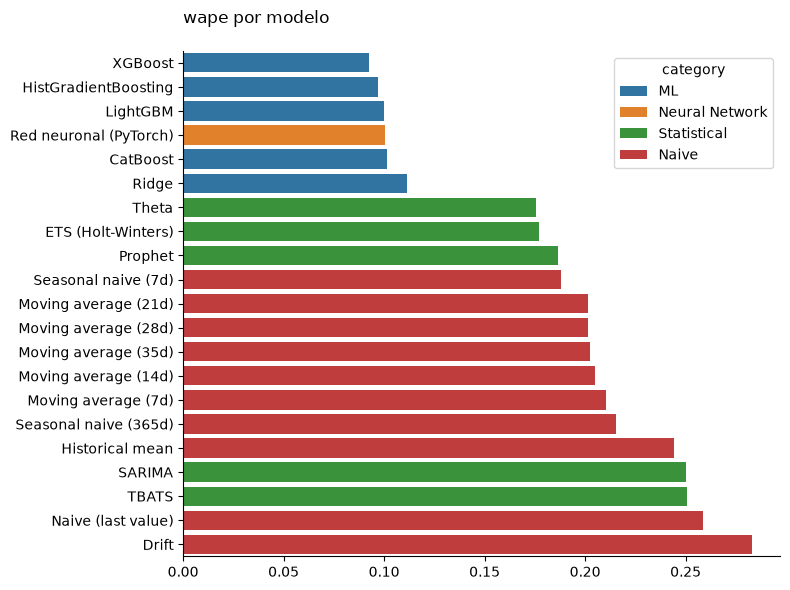

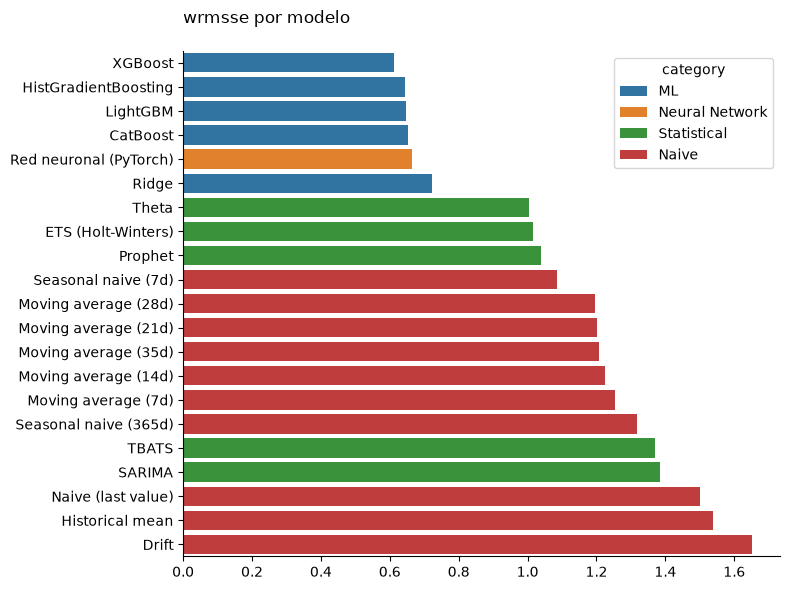

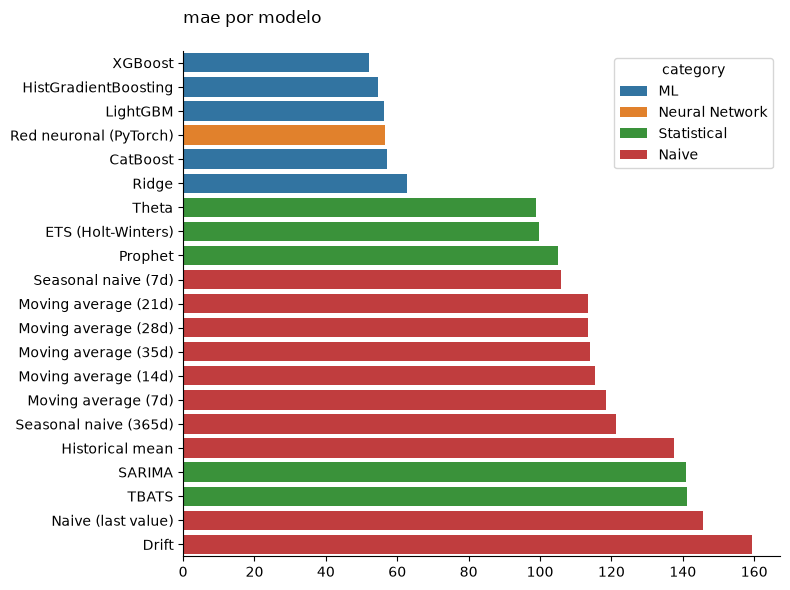

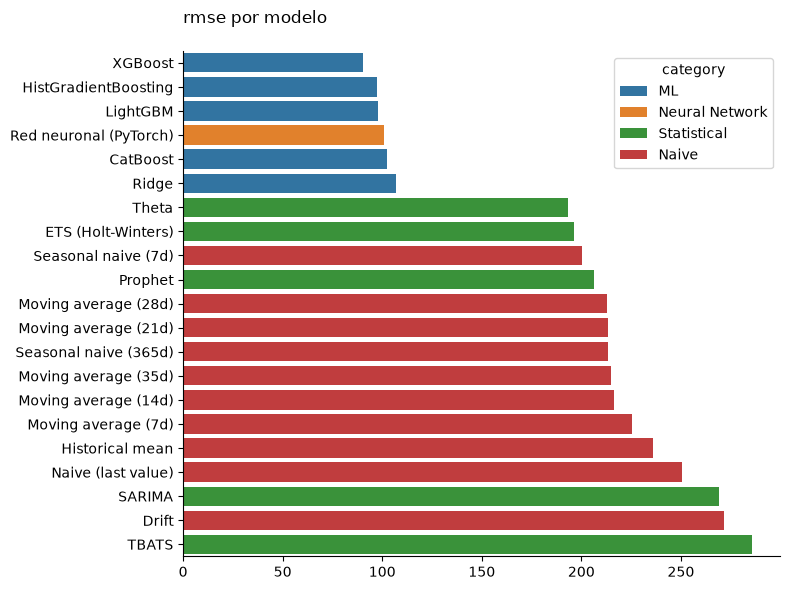

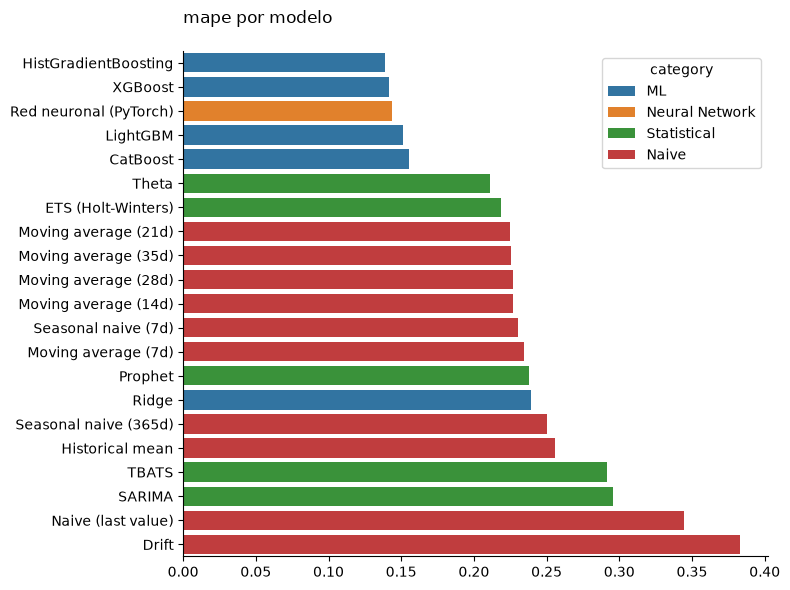

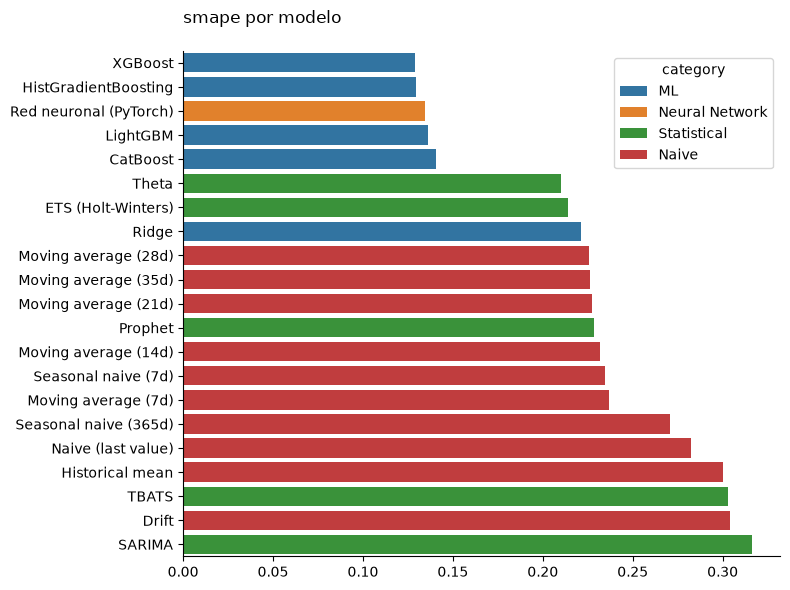

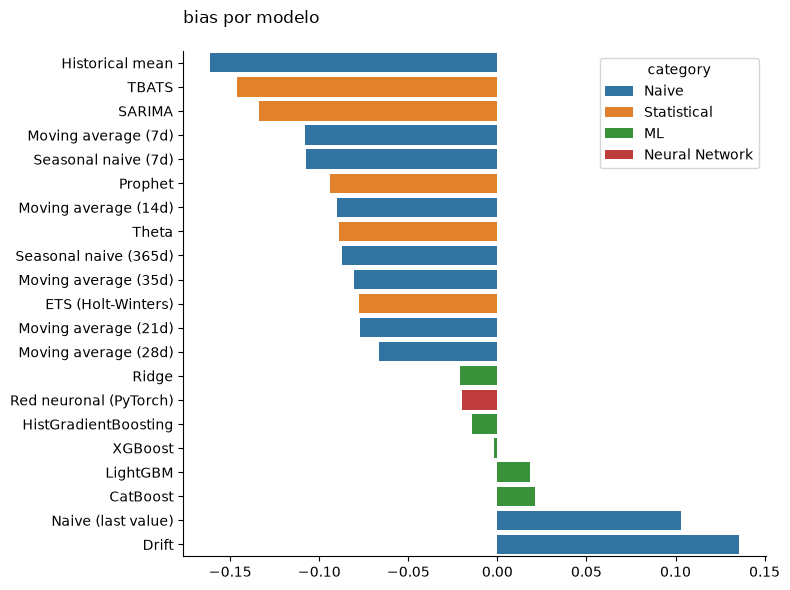

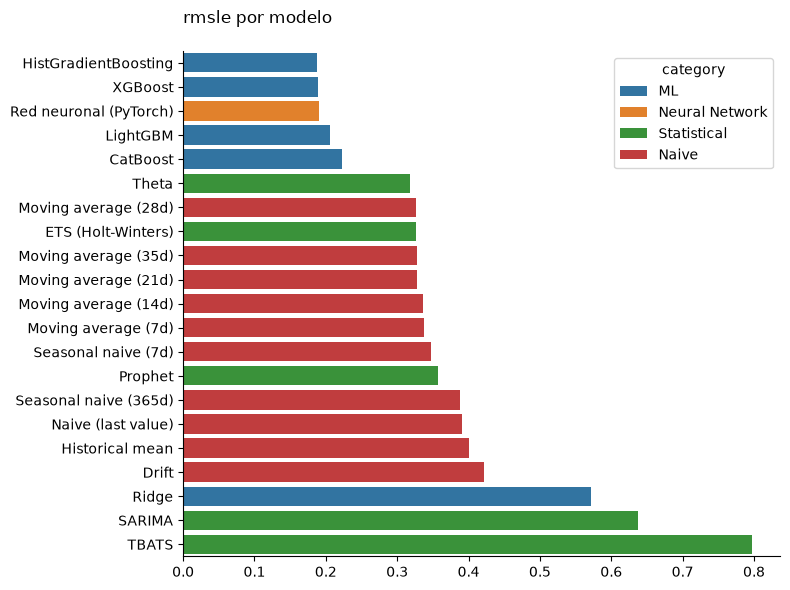

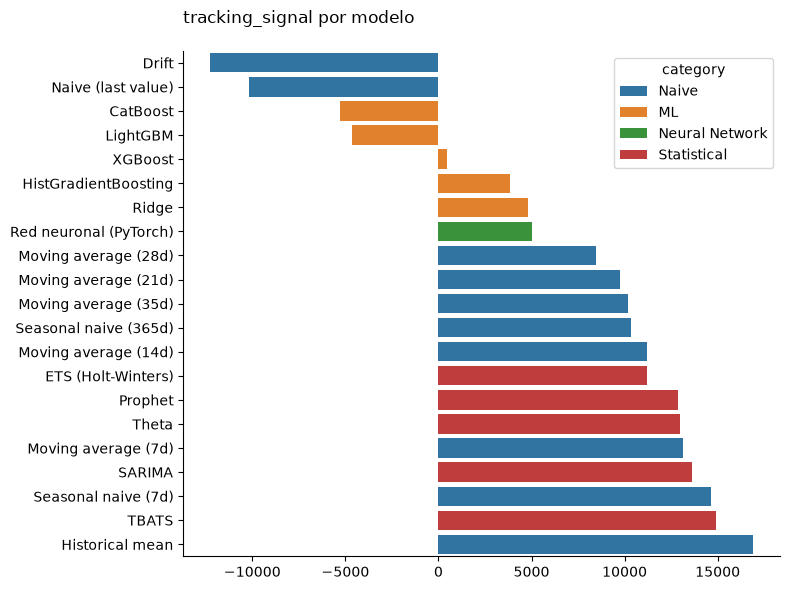

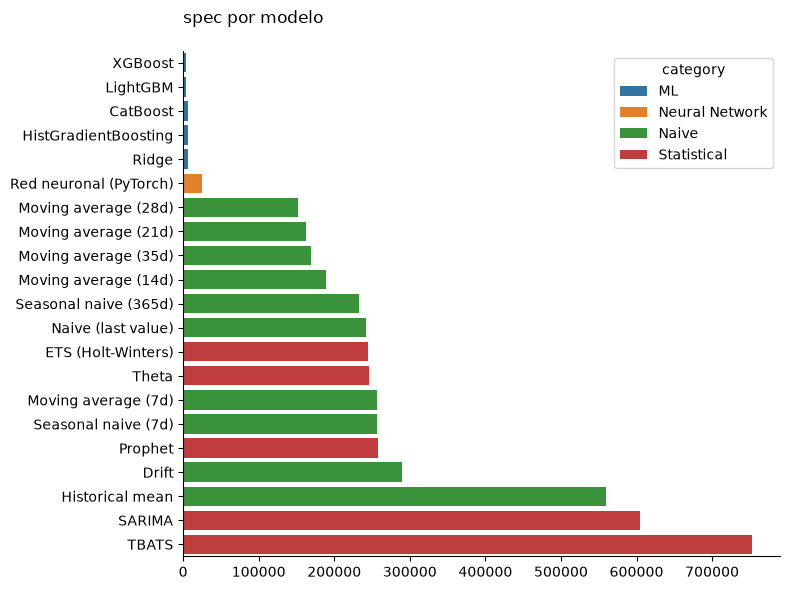

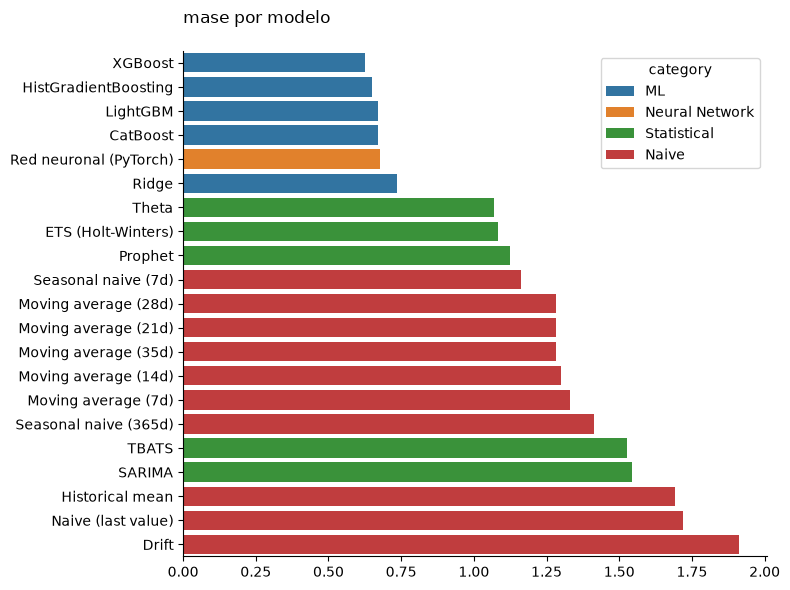

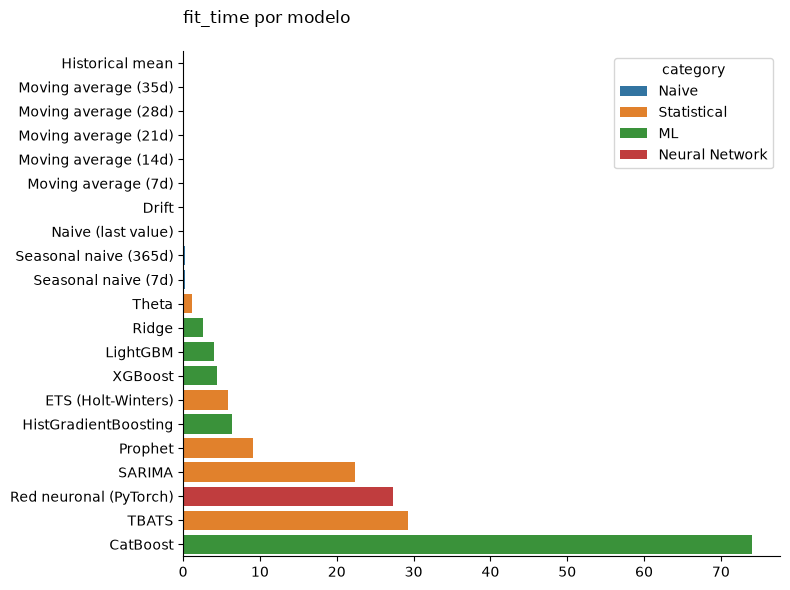

In [34]:
for col in ['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

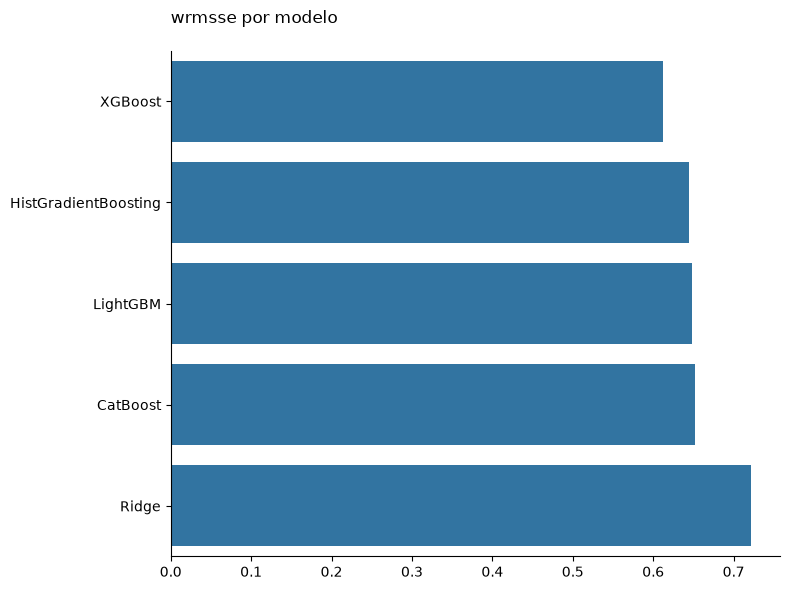

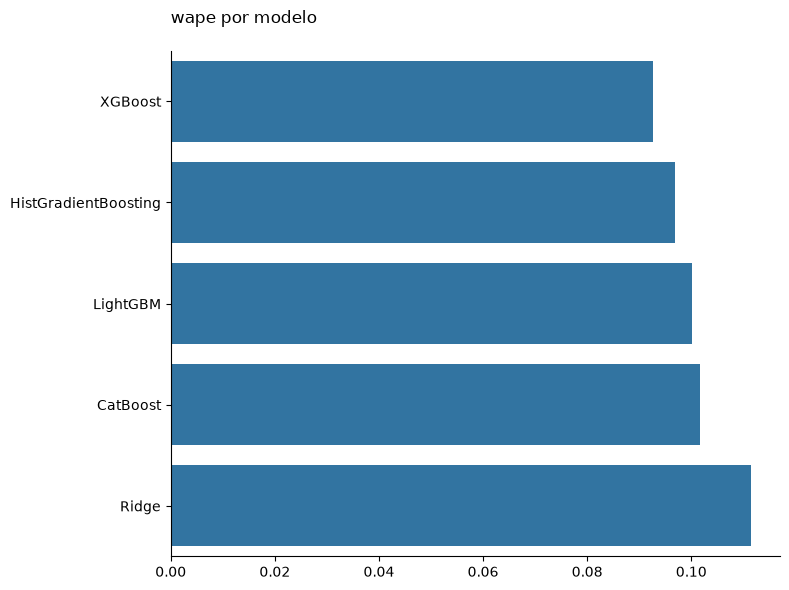

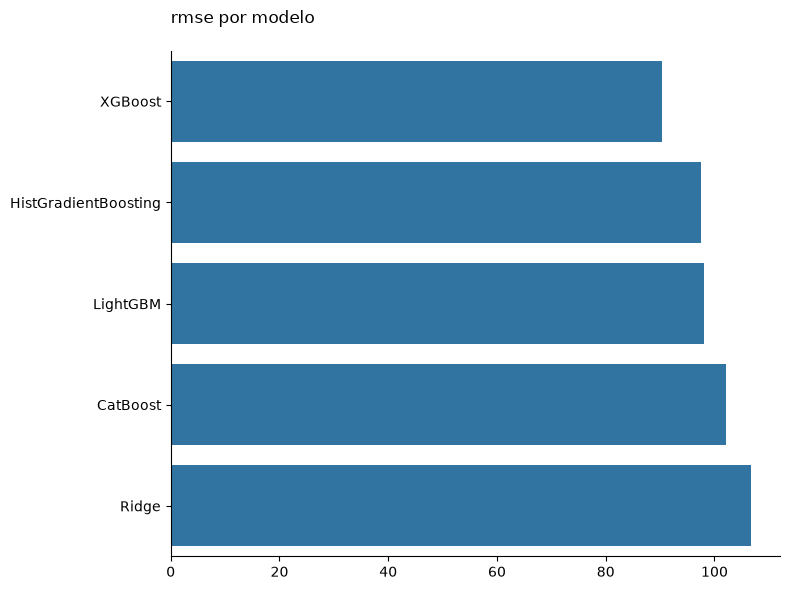

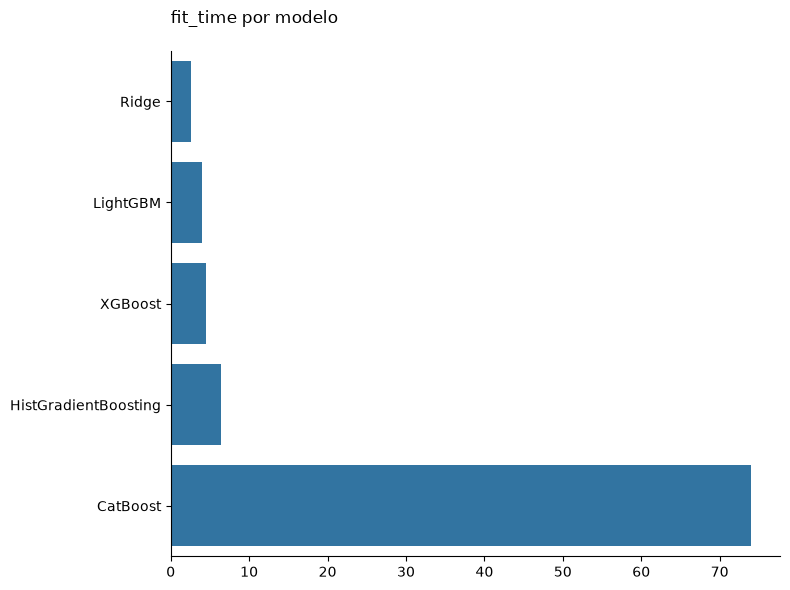

In [35]:
for col in ['wrmsse','wape','rmse', 'fit_time']:
    plot_barh_by_model(results_df.query('category == "ML"'), x=col, y="model", title=f"{col} por modelo")

# Selección de features

El resto del notebook usa LightGBM (velocidad, soporte nativo de categóricas, compatible con SHAP), así que la selección se hace sobre `lgbm_model`. Se comparan dos criterios de importancia (gain del árbol vs. permutation importance sobre validación) y luego se aplica una eliminación hacia atrás (backward elimination): se van descartando las features menos importantes mientras el WRMSSE de validación no empeore más allá de una tolerancia.

## Importancia por ganancia (gain)

In [36]:
importance_gain = (
    pd.Series(lgbm_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)
importance_gain.head(20)

lag1                              8.834689e+10
lag7                              4.758494e+10
rolling_mean_lag7_window_size7    2.863751e+10
lag28                             2.372630e+10
lag21                             3.136297e+09
lag14                             2.976509e+09
lag91                             1.347315e+09
snap                              8.526162e+08
lag35                             6.719130e+08
lag3                              6.145160e+08
dayofweek                         5.819771e+08
lag56                             4.067735e+08
event_name_1                      2.874760e+08
lag182                            2.799248e+08
price_change                      2.593588e+08
is_store_closed                   2.576603e+08
lag364                            2.155521e+08
dept_id                           1.749377e+08
store_id                          1.651656e+08
price_vs_mean                     1.623759e+08
dtype: float64

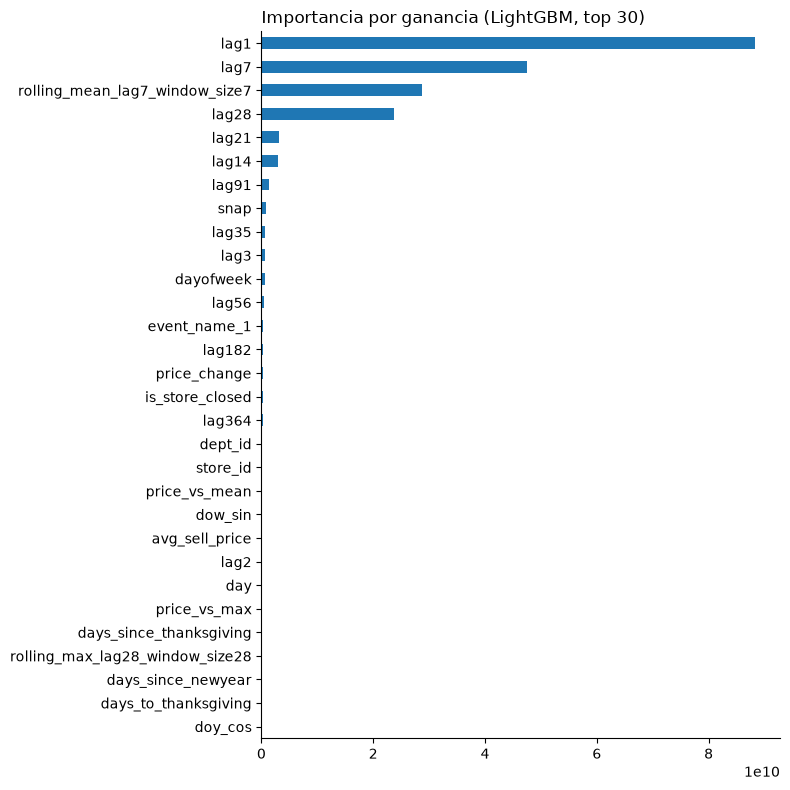

In [37]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_gain.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Importancia por ganancia (LightGBM, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Permutation importance

El gain puede sobreestimar features de alta cardinalidad o muy usadas para splits sin aportar demasiado al error final. La permutation importance mide directamente cuánto empeora el WAPE en validación al mezclar (shuffle) cada columna, así que es un criterio más fiel al desempeño real del modelo.

In [38]:
from src.modeling import compute_permutation_importance

importance_perm = compute_permutation_importance(
    lgbm_model, X_valid, y_valid, FEATURES,
    sample_size=15_000, n_repeats=10, random_state=RANDOM_STATE,
)
importance_perm.head(20)

lag1                               159.349893
lag7                                78.141354
lag28                               33.994117
snap                                17.662017
rolling_mean_lag7_window_size7      15.643948
dayofweek                           11.148030
lag14                                5.574887
event_name_1                         5.463271
dept_id                              5.458305
store_id                             3.899302
days_to_thanksgiving                 3.864486
lag21                                3.773404
price_vs_mean                        3.101690
is_store_closed                      2.994949
price_change                         2.924746
lag364                               1.832669
price_vs_max                         1.764010
lag3                                 1.621121
rolling_max_lag28_window_size28      1.565032
days_since_thanksgiving              1.379891
dtype: float64

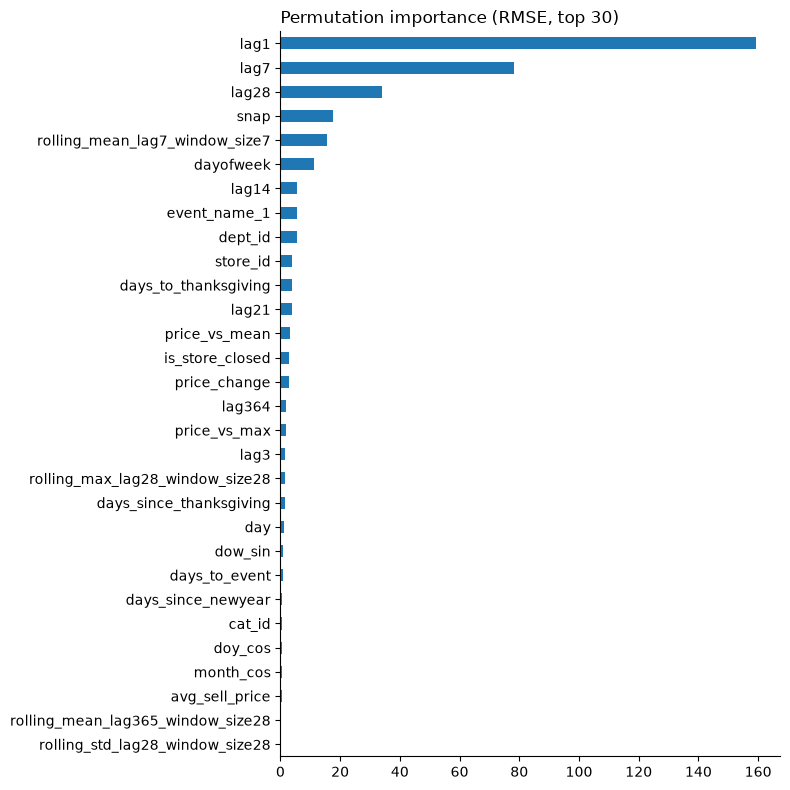

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_perm.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Permutation importance (RMSE, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Eliminación hacia atrás (backward elimination)

Se parte del ranking de permutation importance (de menor a mayor) y se intenta eliminar cada feature: si reentrenar sin ella no empeora el WRMSSE de validación más allá de `TOLERANCE`, se descarta definitivamente.

In [40]:
from src.modeling import backward_feature_selection

selected_features, final_wrmsse, log_df = backward_feature_selection(
    X_train, y_train, X_valid, train, valid,
    FEATURES, CATEGORICAL_FEATURES, importance_perm,
    tolerance=0.001, random_state=RANDOM_STATE,
)

2026-08-23 09:56:59.266 | INFO     | src.modeling.feature_selection:backward_feature_selection:80 - Baseline (104 features): WRMSSE=0.6478
2026-08-23 09:57:02.510 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'rolling_std_lag28_window_size7' -> 103 features | WRMSSE=0.6468
2026-08-23 09:57:06.064 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'rolling_std_lag7_window_size14' -> 102 features | WRMSSE=0.6437
2026-08-23 09:57:09.255 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'rolling_min_lag28_window_size7' -> 101 features | WRMSSE=0.6429
2026-08-23 09:57:12.352 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'lag182' | WRMSSE empeoraría a 0.6490
2026-08-23 09:57:16.020 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'rolling_mean_lag28_window_size7' -> 100 features | WRMSSE=0.6375
2026-08-

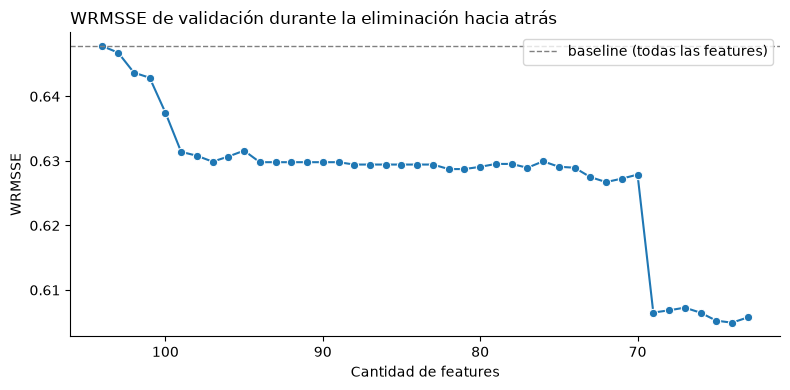

In [41]:
baseline_wrmsse = log_df.loc[log_df["removed"].isna(), "wrmsse"].iloc[0]

# Trayectoria real: baseline + solo las eliminaciones aceptadas, en orden
trajectory = log_df[log_df["accepted"]].sort_values("n_features", ascending=False)
baseline_wrmsse = trajectory["wrmsse"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(trajectory, x="n_features", y="wrmsse", marker="o", ax=ax)
ax.invert_xaxis()
ax.axhline(baseline_wrmsse, color="grey", linestyle="--", linewidth=1, label="baseline (todas las features)")
ax.set_title("WRMSSE de validación durante la eliminación hacia atrás", loc="left")
ax.set_xlabel("Cantidad de features")
ax.set_ylabel("WRMSSE")
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

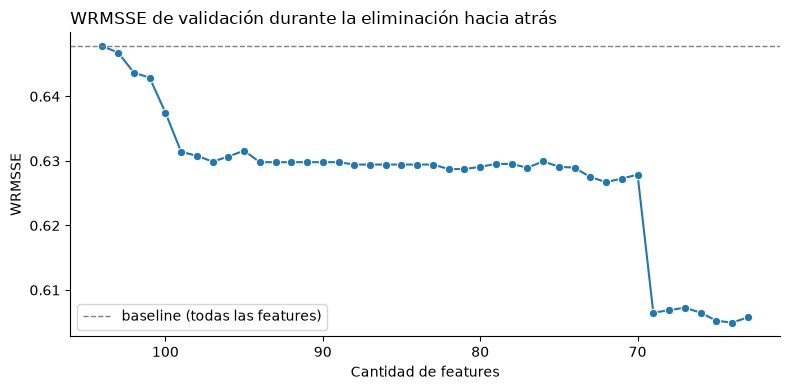

In [42]:
baseline_wrmsse = log_df.loc[log_df["removed"].isna(), "wrmsse"].iloc[0]

# Trayectoria real: baseline + solo las eliminaciones aceptadas, en orden
trajectory = log_df[log_df["accepted"]].sort_values("n_features", ascending=False)
baseline_wrmsse = trajectory["wrmsse"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(trajectory, x="n_features", y="wrmsse", marker="o", ax=ax)
ax.invert_xaxis()
ax.axhline(baseline_wrmsse, color="grey", linestyle="--", linewidth=1, label="baseline (todas las features)")
ax.set_title("WRMSSE de validación durante la eliminación hacia atrás", loc="left")
ax.set_xlabel("Cantidad de features")
ax.set_ylabel("WRMSSE")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Features seleccionadas

Se fija `FEATURES` (y las variables derivadas `X_train`/`X_valid`/`X_test`/`CATEGORICAL_FEATURES`/`NUMERICAL_FEATURES`) al subconjunto seleccionado, para que el resto del notebook (modelo simple, SHAP, tuning con Optuna, modelo final) entrene sobre las features filtradas.

In [43]:
print(f"Features descartadas ({len(FEATURES) - len(selected_features)}): "
      f"{sorted(set(FEATURES) - set(selected_features))}")

FEATURES = selected_features
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in FEATURES]
NUMERICAL_FEATURES = [c for c in NUMERICAL_FEATURES if c in FEATURES]

X_train = X_train[FEATURES]
X_valid = X_valid[FEATURES]
X_test = X_test[FEATURES]

print(f"Features finales: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categóricas)")

Features descartadas (41): ['cv2_90', 'days_to_thanksgiving', 'doy_sin', 'event_name_1', 'event_name_2', 'event_type_2', 'event_type_2_enc', 'has_event', 'has_event_2', 'is_likely_stockout', 'is_month_end', 'is_month_start', 'is_weekend', 'item_id', 'month', 'pct_zero_90', 'price_lag_7', 'quarter', 'rolling_max_lag28_window_size91', 'rolling_max_lag7_window_size14', 'rolling_max_lag7_window_size7', 'rolling_max_lag91_window_size91', 'rolling_mean_lag28_window_size7', 'rolling_mean_lag28_window_size91', 'rolling_mean_lag364_window_size28', 'rolling_mean_lag365_window_size91', 'rolling_mean_lag91_window_size28', 'rolling_mean_lag91_window_size91', 'rolling_min_lag28_window_size7', 'rolling_min_lag7_window_size14', 'rolling_min_lag91_window_size91', 'rolling_std_lag28_window_size7', 'rolling_std_lag28_window_size91', 'rolling_std_lag364_window_size28', 'rolling_std_lag364_window_size91', 'rolling_std_lag7_window_size14', 'rolling_std_lag7_window_size7', 'rolling_std_lag91_window_size28', 

# Modelo simple

In [44]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
from src.evaluation import wape_metric, make_wrmsse_metric

wrmsse_metric = make_wrmsse_metric(train, valid)


In [45]:
model = LGBMRegressor(
    objective="rmse",
)

t0 = time.perf_counter()
model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=[wrmsse_metric,],
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features)", model.predict(X_valid), fit_time=fit_time, category="ML")

Training until validation scores don't improve for 100 rounds
[10]	valid_0's rmse: 242.213	valid_0's wrmsse: 1.44905
[20]	valid_0's rmse: 130.921	valid_0's wrmsse: 0.853835
[30]	valid_0's rmse: 104.405	valid_0's wrmsse: 0.699523
[40]	valid_0's rmse: 97.3202	valid_0's wrmsse: 0.657473
[50]	valid_0's rmse: 94.392	valid_0's wrmsse: 0.64009
[60]	valid_0's rmse: 92.4129	valid_0's wrmsse: 0.629031
[70]	valid_0's rmse: 91.0904	valid_0's wrmsse: 0.621342
[80]	valid_0's rmse: 89.8588	valid_0's wrmsse: 0.614063
[90]	valid_0's rmse: 89.2165	valid_0's wrmsse: 0.609507
[100]	valid_0's rmse: 88.5361	valid_0's wrmsse: 0.605749
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 88.5361	valid_0's wrmsse: 0.605749
Evaluated only: rmse


2026-08-23 10:07:05.489 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - LightGBM (selected features) [ML] | WAPE: 9.15% | WRMSSE: 0.6057 | MAE: 51.517 | RMSE: 88.226 | MAPE: 14.17% | SMAPE: 13.13% | Bias: -0.79% | RMSLE: 0.1970 | TS: 2194.17 | SPEC: 3356.892 | MASE: 0.6175 | fit: 20.07s


{'model': 'LightGBM (selected features)',
 'category': 'ML',
 'wape': 0.09147639169983762,
 'wrmsse': 0.6057489778744973,
 'mae': 51.517198099037216,
 'rmse': 88.22626472470319,
 'mape': 0.14167733040481761,
 'smape': 0.1312698238443964,
 'bias': -0.007855778831451738,
 'rmsle': 0.1970483134800905,
 'tracking_signal': 2194.174315513017,
 'spec': 3356.8920227367094,
 'mase': 0.6175230286118513,
 'fit_time': 20.066490742000042}

## Explicación modelo

In [46]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

In [47]:
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                             feature  mean_abs_shap
29                              lag1     173.811846
32                              lag7      85.562868
42    rolling_mean_lag7_window_size7      47.896819
35                             lag28      47.497725
34                             lag21      20.539402
..                               ...            ...
16                  event_type_1_enc       0.138719
45    rolling_max_lag28_window_size7       0.132391
57  rolling_max_lag364_window_size28       0.125064
23                  price_volatility       0.087143
27                       pct_zero_28       0.004412

[63 rows x 2 columns]


### Importancia global de features

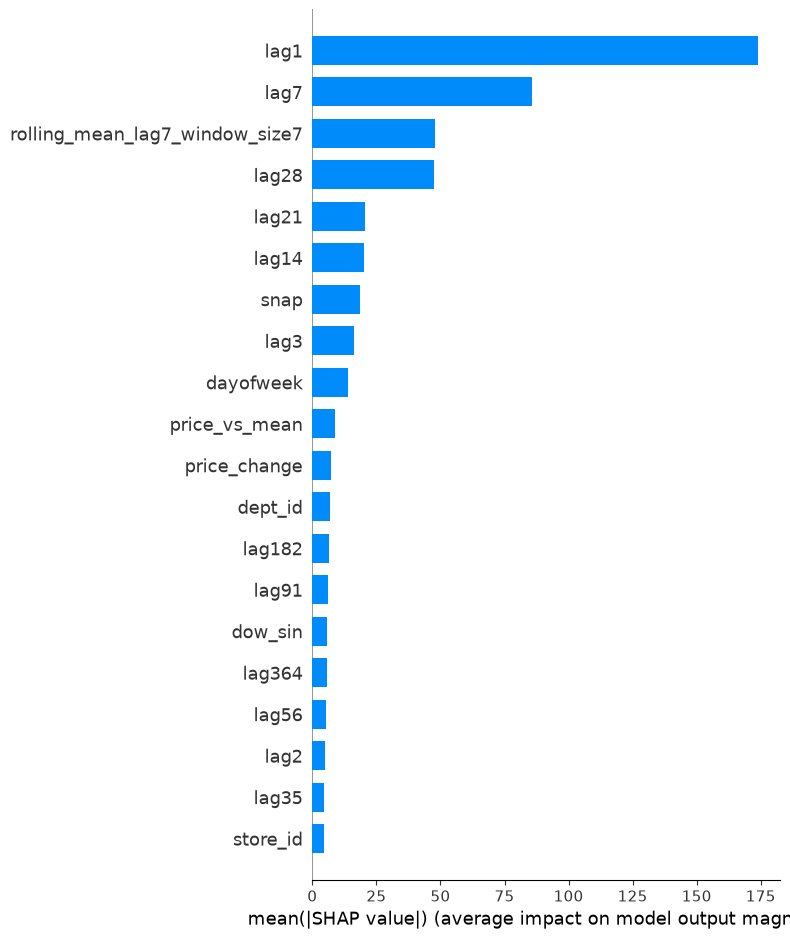

In [48]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

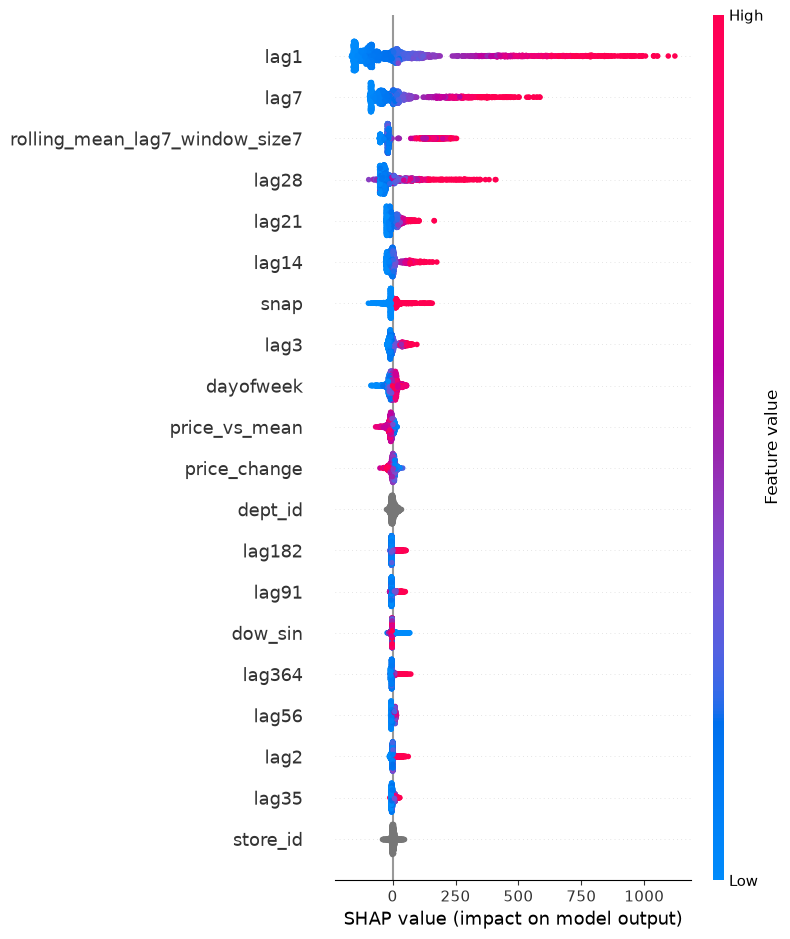

In [49]:
shap.summary_plot(shap_values, X_shap)

### Dependencia por feature

Feature más importante: lag1


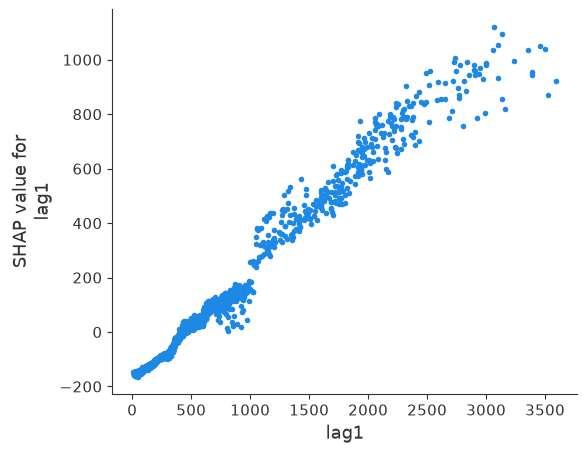

In [50]:
top_feature = X_shap.columns[np.argsort(-np.abs(shap_values).mean(axis=0))[0]]
print(f"Feature más importante: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_shap, interaction_index=None)

# Predicciones

In [51]:
from src.evaluation import explain_prediction


In [52]:
from src.evaluation import plot_forecast


In [53]:
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, TARGET, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )


In [54]:
from src.evaluation.metrics import build_predictions_report

metrics_test, df_pred = build_predictions_report(train, test, y_test, model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test['wrmsse']:.4f}")

Test WAPE: 8.88%
Test WRMSSE: 0.6278


In [55]:
#from src.evaluation.metrics import build_series_metrics

#df_metrics = build_series_metrics(train, df_pred, target_col=TARGET, weight_level=["date"])
#df_metrics.head(10)

In [56]:
#df_pred.query('agg_id == "FOODS_3_FOODS_CA_3_CA"').nlargest(10, 'wape')

In [57]:
#_analizar_prediccion('TOTAL', '2016-05-16',)

# Modelo optimizado

In [58]:
import optuna
from optuna.integration import LightGBMPruningCallback
import lightgbm as lgb
import numpy as np

In [59]:
import lightgbm as lgb
import numpy as np
import optuna
from optuna.integration import LightGBMPruningCallback

In [60]:
def objective(trial):
    model = lgb.LGBMRegressor(
        objective="rmse",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        n_estimators=1500,
        num_leaves=trial.suggest_int("num_leaves", 31, 255),
        max_depth=trial.suggest_int("max_depth", 5, 10),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 5, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 5, log=True),
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        categorical_feature=CATEGORICAL_FEATURES,
        callbacks=[
            lgb.early_stopping(30, first_metric_only=True, verbose=False),
            LightGBMPruningCallback(trial, "rmse"),
        ],
    )
    y_pred = model.predict(X_valid, num_iteration=model.best_iteration_)
    _, final_wrmsse, _ = wrmsse_metric(y_valid, y_pred)
    return final_wrmsse

In [63]:
study = optuna.create_study(
    study_name=f"study_{LEVEL}", 
    direction="minimize",
    storage="sqlite:///../artifacts/optuna_study.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=42,
    ),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10, n_startup_trials=5),
)

study.optimize(
    objective,
    n_trials=1_000,
    timeout=60 * 15,
    show_progress_bar=True,
)

best_trial = study.best_trial
print(f"Mejor WRMSSE: {best_trial.value:.4f}")
print("Mejores hiperparámetros:", best_trial.params)

[I 2026-08-23 10:19:27,210] A new study created in RDB with name: study_level_09_daily_store_dept


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2026-08-23 10:21:03,339] Trial 0 finished with value: 0.58948076424215 and parameters: {'learning_rate': 0.054816785328198704, 'num_leaves': 244, 'max_depth': 9, 'min_child_samples': 128, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0016400214911202306, 'reg_lambda': 1.599409170128044}. Best is trial 0 with value: 0.58948076424215.
[I 2026-08-23 10:22:16,635] Trial 1 finished with value: 0.59273011571749 and parameters: {'learning_rate': 0.07893736353172352, 'num_leaves': 190, 'max_depth': 5, 'min_child_samples': 195, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.004705059281907645, 'reg_lambda': 0.004768785415482609}. Best is trial 0 with value: 0.58948076424215.
[I 2026-08-23 10:23:49,588] Trial 2 finished with value: 0.5857344115272373 and parameters: {'learning_rate': 0.048952790869270256, 'num_leaves': 149, 'max_depth': 7, 'min_child_samples': 72, 'subsample': 0.8447411578889518, 'colsample_bytr

# Modelo final

In [64]:
model_params = best_trial.params

final_model = lgb.LGBMRegressor(
    objective="rmse",
    n_estimators=1_500,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    subsample_freq=1,
    **model_params,
)

t0 = time.perf_counter()
final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=wrmsse_metric,
    categorical_feature=CATEGORICAL_FEATURES,
    callbacks=[
        lgb.early_stopping(50, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features | Optuna)", final_model.predict(X_valid), fit_time=fit_time, category="ML")

Training until validation scores don't improve for 50 rounds
[10]	valid_0's rmse: 446.741	valid_0's wrmsse: 2.53653
[20]	valid_0's rmse: 329.169	valid_0's wrmsse: 1.89584
[30]	valid_0's rmse: 247.765	valid_0's wrmsse: 1.45333
[40]	valid_0's rmse: 192.975	valid_0's wrmsse: 1.1561
[50]	valid_0's rmse: 157.468	valid_0's wrmsse: 0.959771
[60]	valid_0's rmse: 134.476	valid_0's wrmsse: 0.832184
[70]	valid_0's rmse: 120.619	valid_0's wrmsse: 0.752157
[80]	valid_0's rmse: 111.924	valid_0's wrmsse: 0.701868
[90]	valid_0's rmse: 106.511	valid_0's wrmsse: 0.669201
[100]	valid_0's rmse: 103.03	valid_0's wrmsse: 0.649267
[110]	valid_0's rmse: 100.702	valid_0's wrmsse: 0.637029
[120]	valid_0's rmse: 98.6499	valid_0's wrmsse: 0.626425
[130]	valid_0's rmse: 97.0027	valid_0's wrmsse: 0.618637
[140]	valid_0's rmse: 95.8368	valid_0's wrmsse: 0.613823
[150]	valid_0's rmse: 95.0652	valid_0's wrmsse: 0.61046
[160]	valid_0's rmse: 94.3368	valid_0's wrmsse: 0.607486
[170]	valid_0's rmse: 93.828	valid_0's wrms

2026-08-23 10:42:15.830 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - LightGBM (selected features | Optuna) [ML] | WAPE: 8.84% | WRMSSE: 0.5827 | MAE: 49.773 | RMSE: 86.978 | MAPE: 14.04% | SMAPE: 12.49% | Bias: -0.07% | RMSLE: 0.1852 | TS: 202.66 | SPEC: 4517.111 | MASE: 0.5917 | fit: 432.48s


{'model': 'LightGBM (selected features | Optuna)',
 'category': 'ML',
 'wape': 0.08837945801950582,
 'wrmsse': 0.5826889032113847,
 'mae': 49.77308310997259,
 'rmse': 86.97830524931737,
 'mape': 0.14039006798658074,
 'smape': 0.12493459783779293,
 'bias': -0.0007010003827051474,
 'rmsle': 0.18520847677946115,
 'tracking_signal': 202.65523436637912,
 'spec': 4517.110545296331,
 'mase': 0.5917382491805723,
 'fit_time': 432.47892146999993}

## Resultados finales

In [65]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse").query('wape <= 0.15')
results_df

,model,category,wape,wrmsse,mae,rmse,mape,smape,bias,rmsle,tracking_signal,spec,mase,fit_time
22,LightGBM (selected features | Optuna),ML,0.088379,0.582689,49.773083,86.978305,0.140390,0.124935,-0.000701,0.185208,202.655234,4517.110545,0.591738,432.478921
21,LightGBM (selected features),ML,0.091476,0.605749,51.517198,88.226265,0.141677,0.131270,-0.007856,0.197048,2194.174316,3356.892023,0.617523,20.066491
16,XGBoost,ML,0.092615,0.612505,52.158519,90.430386,0.141738,0.129003,-0.001691,0.188974,466.394975,3959.035213,0.624418,4.455997
18,HistGradientBoosting,ML,0.096821,0.644081,54.527418,97.586194,0.138676,0.129569,-0.014509,0.187520,3828.660092,5952.123200,0.650278,6.360755
15,LightGBM,ML,0.100180,0.647779,56.418605,98.055422,0.151103,0.136132,0.018173,0.205416,-4634.946620,4075.085124,0.670139,3.996300
17,CatBoost,ML,0.101598,0.651572,57.217203,102.185187,0.155435,0.140754,0.020923,0.222400,-5261.866410,5813.178936,0.670498,73.994861
20,Red neuronal (PyTorch),Neural Network,0.100282,0.664811,56.451958,101.112627,0.143616,0.134509,-0.019733,0.189865,5027.640505,24816.267371,0.677905,27.297045
19,Ridge,ML,0.111466,0.721619,62.775077,106.710846,0.239579,0.221503,-0.021097,0.572254,4835.779191,6218.032516,0.736770,2.553791


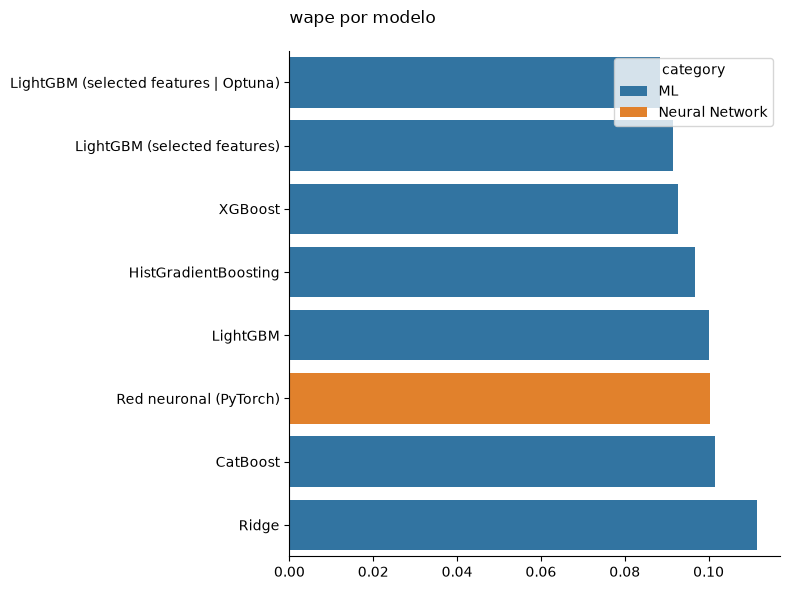

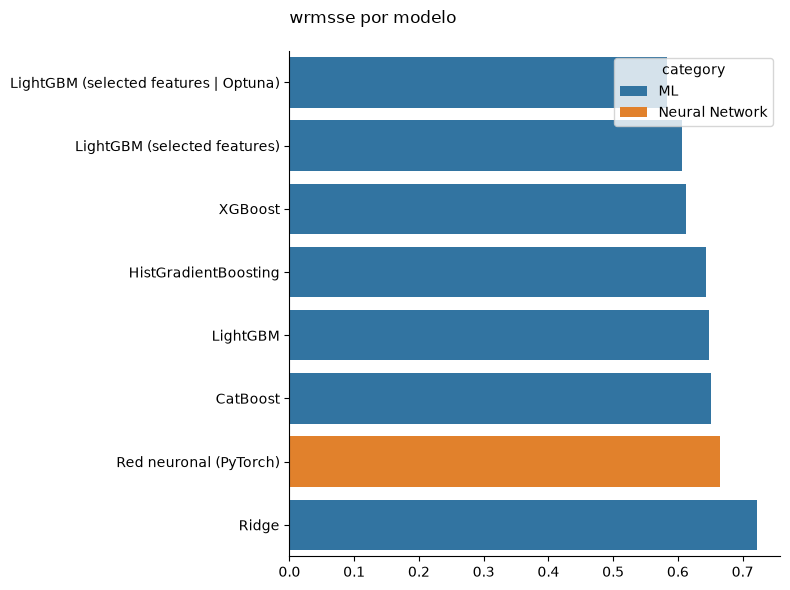

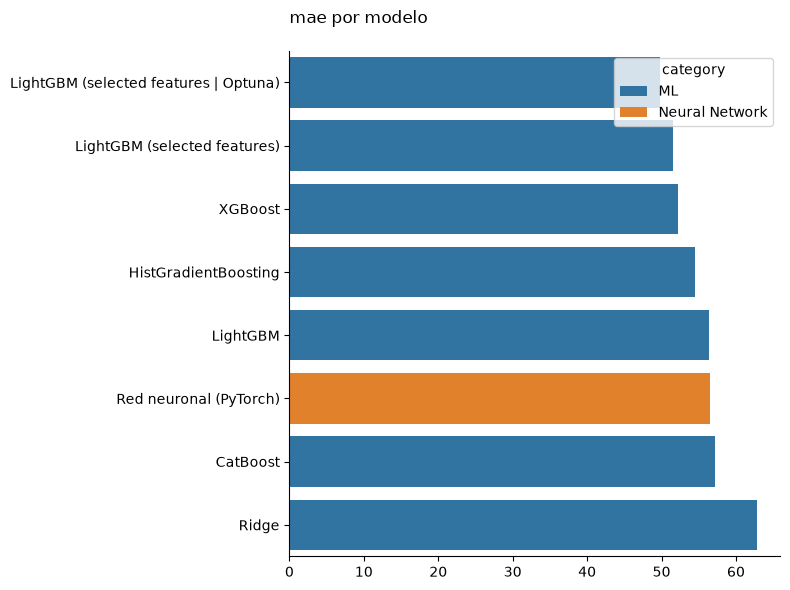

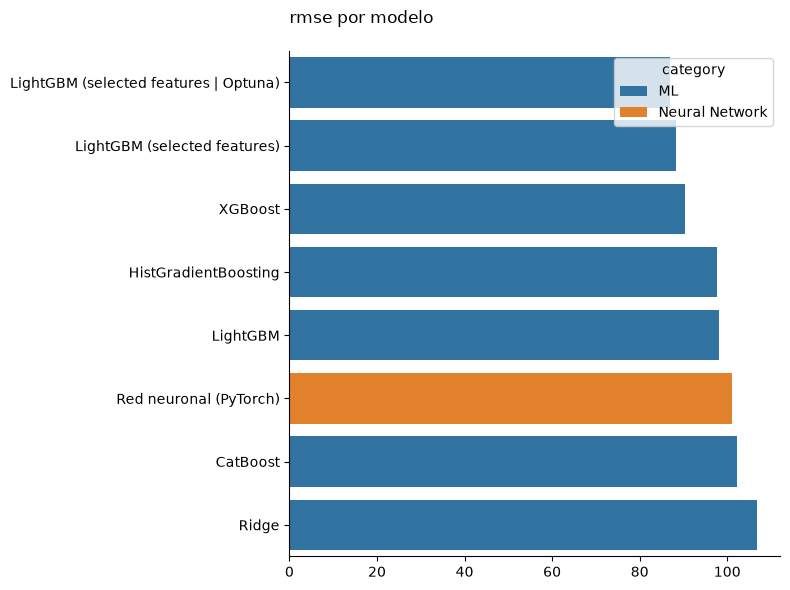

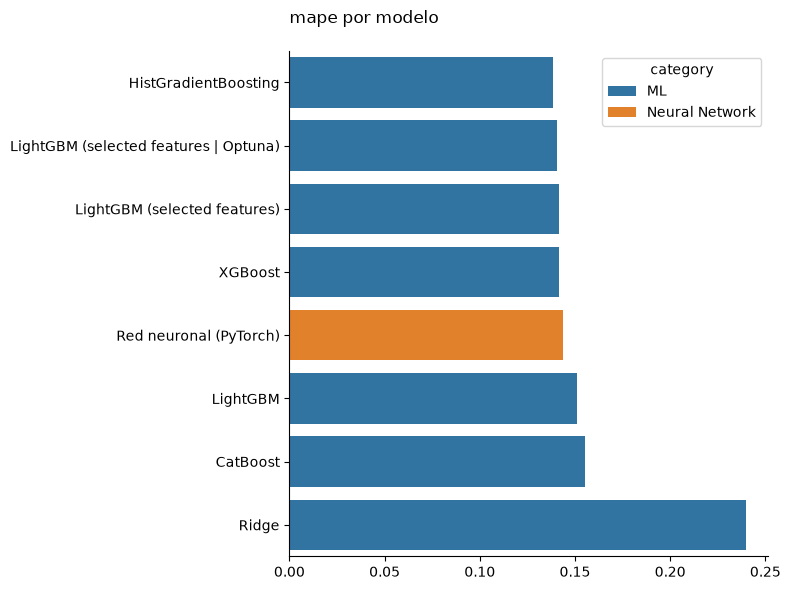

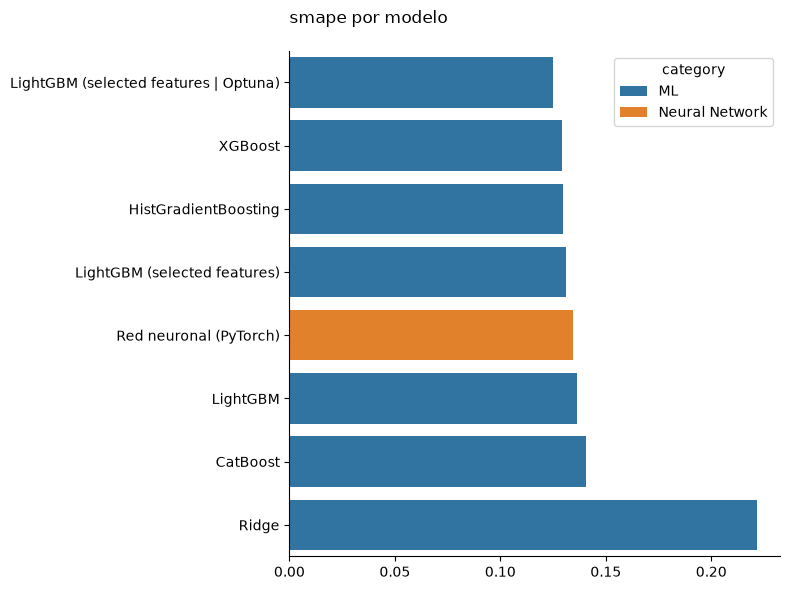

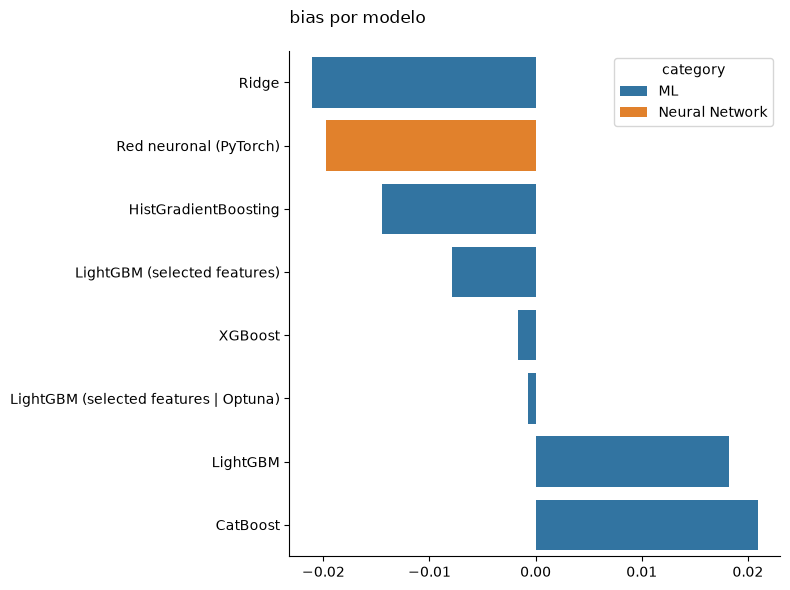

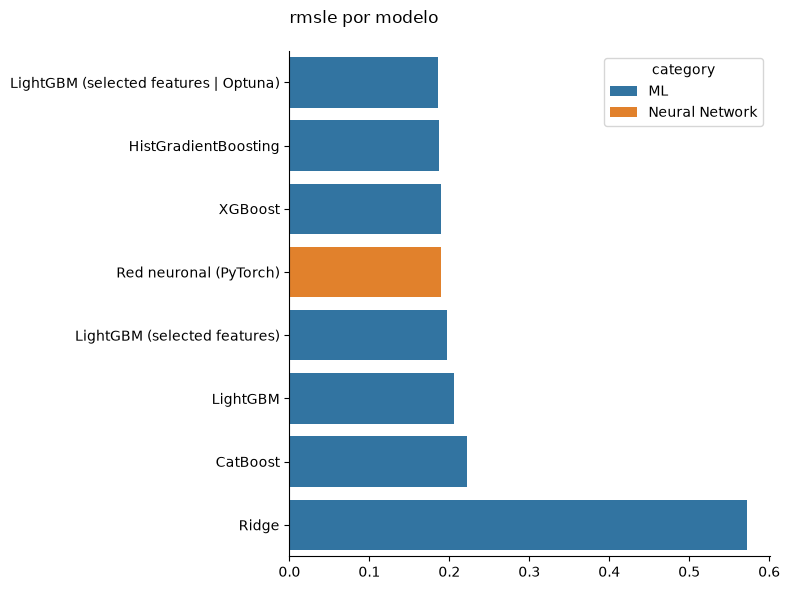

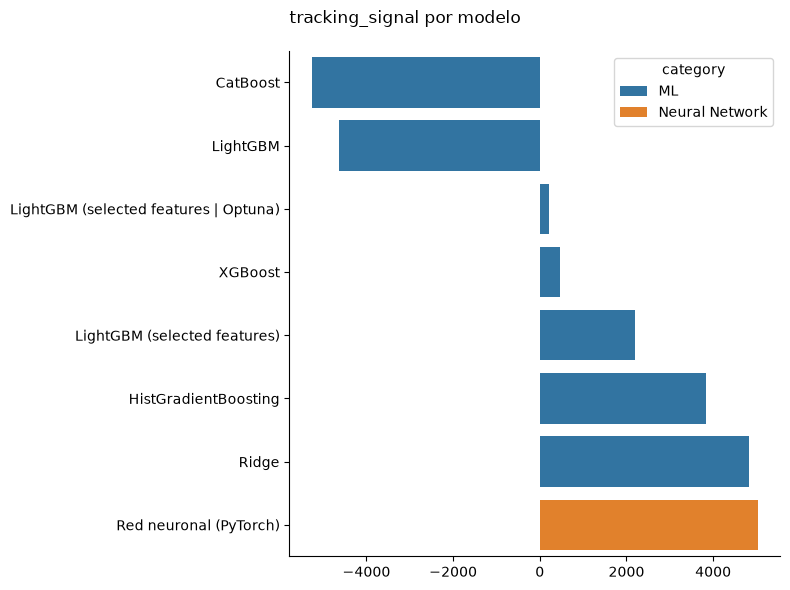

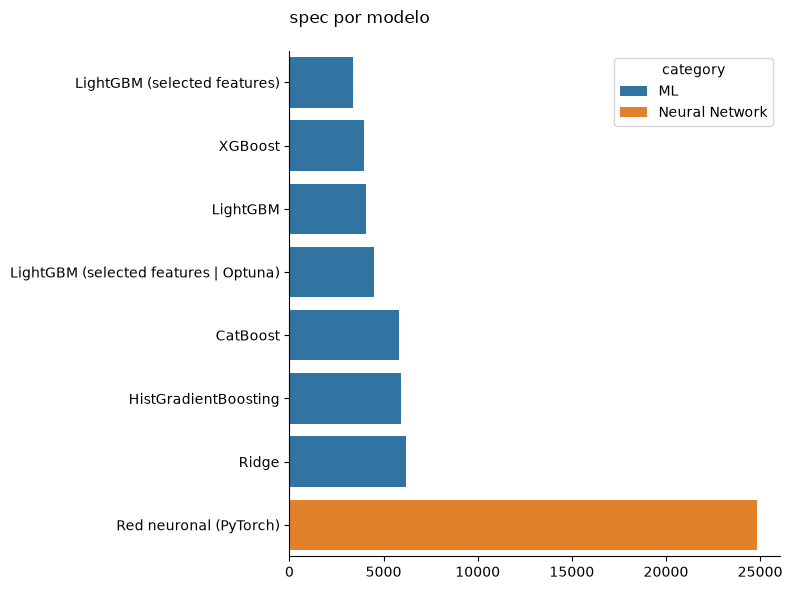

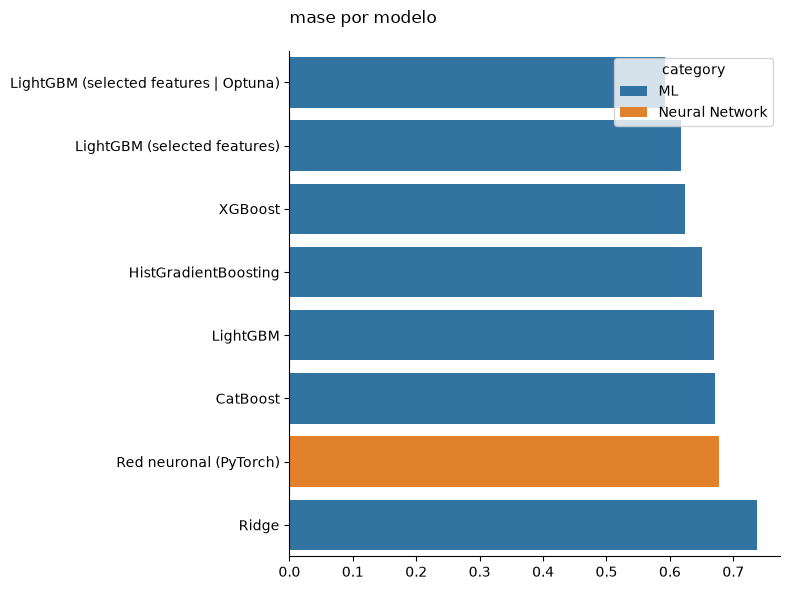

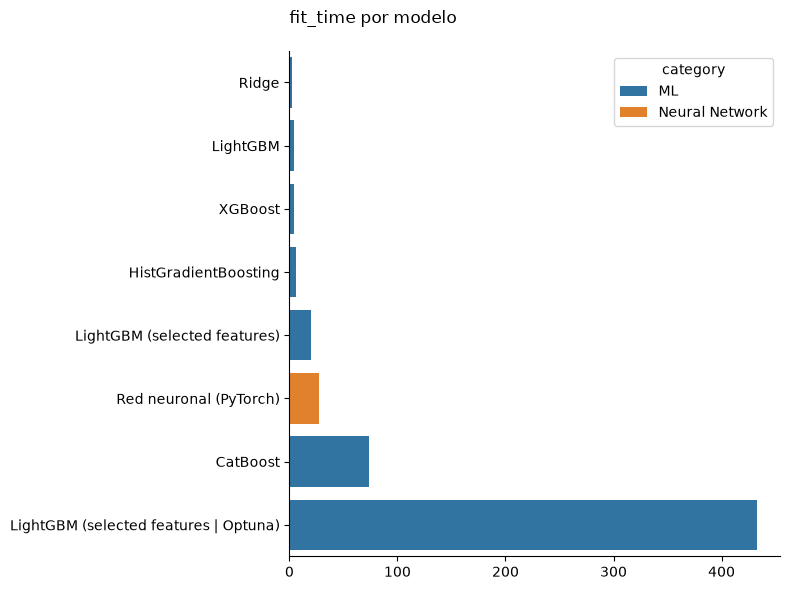

In [66]:
for col in ['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

# Exploración modelo final

In [67]:
metrics_test_final, df_pred = build_predictions_report(train, test, y_test, final_model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 8.68%
Test WRMSSE: 0.6159


In [68]:
# from src.evaluation.metrics import build_series_metrics

# df_metrics = build_series_metrics(train, df_pred, target_col=TARGET, weight_level=["date"])
# df_metrics.head(10)

In [69]:
# df_pred.query('agg_id == "FOODS_3_FOODS_CA_3_CA"').nlargest(10, 'wape')

In [70]:
# analizar_prediccion('FOODS_3_FOODS_CA_3_CA', '2016-05-15',)

# Exportar

In [76]:
import joblib

feature_importance = (
    pd.Series(final_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)

artifact = {
    # modelo y datos de trabajo
    "level": LEVEL,
    "df": df,
    "model": final_model,
    "model_params": model_params,
    "metrics_results": results_df,
    "X_train": X_train,
    "y_train": y_train,
    "X_valid": X_valid,
    "y_valid": y_valid,
    "X_test": X_test,
    "y_test": y_test,
    "train": train,
    "valid": valid,
    "test": test,
    # features y columnas
    "features": FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "numerical_features": NUMERICAL_FEATURES,
    "id_cols": ID_COLS,
    "leaky_cols": LEAKY_COLS,
    "target": TARGET,
    "feature_importance": feature_importance,
    # predicciones y métricas del modelo final (test)
    #"df_pred": df_pred,
    #"df_metrics": df_metrics,
    # comparación de todos los modelos probados (validación)
    "model_results": model_results,
    "results_df": results_df,
    #"series_metrics_valid": series_metrics_df,
    # metadatos
    "wape_valid": model_results[-1]["wape"],
    "wrmsse_valid": model_results[-1]["wrmsse"],
    "wape_test": metrics_test_final["wape"],
    "wrmsse_test": metrics_test_final["wrmsse"],
    "train_start": str(first_date.date()),
    "valid_start": str(valid_start.date()),
    "test_start": str(test_start.date()),
}

artifact_path = f"../artifacts/models/{LEVEL}_{TARGET}_artifact.pkl"
joblib.dump(artifact, artifact_path)
print(f"Artifact guardado en {artifact_path}")

Artifact guardado en ../artifacts/models/level_09_daily_store_dept_sales_artifact.pkl
